In [3]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Batch 21cmFAST Coeval Runs (grid sweep over parameters)

Purpose (non-expert summary)
---------------------------
This script runs the same simulation multiple times while changing:
  1) random seed  (controls stochastic realizations)
  2) M_TURN       (an astrophysical model parameter)
  3) F_ESC10      (an astrophysical model parameter)

For each (seed, M_TURN, F_ESC10) combination, it:
  - generates initial conditions,
  - finds halos at the target redshift,
  - runs one "coeval" simulation snapshot at that redshift,
  - saves the resulting 3D grids (density, ionization, temperature, velocities)
    plus halo data into a uniquely named output directory.

FIX: APPLY_RSDS does not exist in this v4 beta build — removed entirely.
     RSD corrections can be applied in post-processing via py21cmfast.rsds module.
"""

import os
os.environ["OMP_NUM_THREADS"] = "8"
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

import time
import gc
import numpy as np
import py21cmfast as p21c
from py21cmfast import InputParameters


# =============================================================================
# 1) TARGET REDSHIFT (we run ONE snapshot: z = zlist[gid])
# =============================================================================
zlist = [
    40.000000, 28.899476, 23.153921, 19.553736, 17.050835, 15.192528,
    13.748622, 12.58864, 11.632645, 10.828694, 10.14145, 9.545964,
    9.024079, 8.562235, 8.150086, 7.77959, 7.444391, 7.139393,
    6.860463, 6.604205, 6.367804, 6.148904, 5.945518, 5.755954,
    5.578765, 5.412706, 5.256697, 5.109794, 4.971176
]
gid = 17
z = zlist[gid]


# =============================================================================
# 2) SIMULATION GRID / BOX SETTINGS
# =============================================================================
HII_DIM = 128
DIM = 3*HII_DIM
BOX_LEN = 800.0


# =============================================================================
# 3) PARAMETER SWEEP
# =============================================================================
seed_list    = [1000]
M_TURN_list  = [9.0]
F_ESC10_list = [-1.0]


# =============================================================================
# 4) OUTPUT LOCATION
# =============================================================================
BASE_OUT = "Test_Sim"
os.makedirs(BASE_OUT, exist_ok=True)


# =============================================================================
# 5) FIXED MODEL SETTINGS
# =============================================================================
cosmo_params = {
    "SIGMA_8": 0.829,
    "hlittle": 0.678,
    "OMm": 0.308,
    "OMb": 0.0482,
    "POWER_INDEX": 0.961,
    "OMn": 0.0,
    "OMk": 0.0,
    "OMr": 8.6e-05,
    "OMtot": 1.0,
    "Y_He": 0.24,
    "wl": -1.0
}

matter_options = {
    "HMF": "ST",
    "USE_RELATIVE_VELOCITIES": False,
    "POWER_SPECTRUM": "EH",
    "FILTER": "spherical-tophat",
    "HALO_FILTER": "spherical-tophat",
    "DEXM_OPTIMIZE": True,
    "SMOOTH_EVOLVED_DENSITY_FIELD": True,
    "USE_INTERPOLATION_TABLES": "hmf-interpolation",
    "USE_FFTW_WISDOM": True,
    "USE_HALO_FIELD": True,
    "KEEP_3D_VELOCITIES": True      # keep velocities so RSDs can be applied in post
}

simulation_options = {
    "BOX_LEN": BOX_LEN,
    "HII_DIM": HII_DIM,
    "DIM": DIM,
    "N_THREADS": 1,
    "SAMPLER_MIN_MASS": 8e7,
    "INITIAL_REDSHIFT": 300.0,
    "Z_HEAT_MAX": 35.0,
    "ZPRIME_STEP_FACTOR": 1.02,
    # NOTE: APPLY_RSDS does not exist in this v4 build.
    # Velocities are saved (KEEP_3D_VELOCITIES=True above) so you can
    # apply RSDs in post-processing using py21cmfast.rsds if needed.
}

astro_options = {
    "USE_MINI_HALOS": False,
    "INHOMO_RECO": True,
    "USE_TS_FLUCT": True,
    "USE_MASS_DEPENDENT_ZETA": True,
    "CELL_RECOMB": True,
    "PHOTON_CONS_TYPE": "no-photoncons",
    "USE_EXP_FILTER": True,
    "AVG_BELOW_SAMPLER": True,
    "HII_FILTER": "spherical-tophat",
    "HEAT_FILTER": "spherical-tophat"
}


# =============================================================================
# 6) ONE-RUN WORKFLOW
# =============================================================================
def run_one_case(seed: int, M_TURN: float, F_ESC10: float) -> None:
    st = time.time()

    astro_params = {
        "HII_EFF_FACTOR": 10.0,
        "F_STAR10": -1.1,
        "ALPHA_STAR": 0.5,
        "F_ESC10": F_ESC10,
        "ALPHA_ESC": -0.5,
        "M_TURN": M_TURN,
        "ION_Tvir_MIN": 4.69897,
        "L_X": 40.5,
        "R_BUBBLE_MAX": 50.0,
        "R_BUBBLE_MIN": 0.6,
        "CLUMPING_FACTOR": 2.0,
        "ALPHA_UVB": 5.0
    }

    inputs = InputParameters(
        random_seed=seed,
        cosmo_params=cosmo_params,
        matter_options=matter_options,
        simulation_options=simulation_options,
        astro_options=astro_options,
        astro_params=astro_params,
        node_redshifts=zlist
    )

    # STEP A: Initial conditions
    init_box = p21c.compute_initial_conditions(inputs=inputs)

    # STEP B: Halos at target redshift
    halolist_init = p21c.determine_halo_list(
        redshift=z,
        initial_conditions=init_box,
        inputs=inputs
    )

    masses = halolist_init.get("halo_masses")
    coords = halolist_init.get("halo_coords")

    mask   = masses > 10.0**9.5
    coords = coords[mask, :]
    masses = masses[mask]

    # STEP C: Coeval snapshot
    sim = p21c.run_coeval(
        inputs=inputs,
        out_redshifts=z,
        write=False,
    )

    density     = sim[0].density
    xH          = sim[0].neutral_fraction
    temperature = sim[0].kinetic_temperature
    vx, vy, vz  = sim[0].velocity_x, sim[0].velocity_y, sim[0].velocity_z

    # STEP D: Save outputs
    out_dir = os.path.join(
        BASE_OUT,
        f"seed{seed}_MTURN{M_TURN:.1f}_FESC{F_ESC10:.2f}_z{z:.2f}"
    )
    os.makedirs(out_dir, exist_ok=True)

    np.save(os.path.join(out_dir, "density_grid_017.npy"),     density)
    np.save(os.path.join(out_dir, "xHII_grid_017.npy"),        1 - xH)
    np.save(os.path.join(out_dir, "temperature_grid_017.npy"), temperature)
    np.save(os.path.join(out_dir, "velocity_vx_grid_017.npy"), vx)
    np.save(os.path.join(out_dir, "velocity_vy_grid_017.npy"), vy)
    np.save(os.path.join(out_dir, "velocity_vz_grid_017.npy"), vz)
    np.save(os.path.join(out_dir, "halo_coords_grid_017.npy"), coords)
    np.save(os.path.join(out_dir, "halo_masses_grid_017.npy"), masses)

    runtime = time.time() - st
    with open(os.path.join(out_dir, "metadata.txt"), "w") as f:
        f.write("Batch 21cmFAST run metadata\n")
        f.write("---------------------------\n")
        f.write(f"Target redshift z = {z:.3f}  (gid={gid})\n\n")
        f.write("Varied parameters in this batch:\n")
        f.write(f"  random_seed = {seed}\n")
        f.write(f"  M_TURN      = {M_TURN}\n")
        f.write(f"  F_ESC10     = {F_ESC10}\n\n")
        f.write("Fixed simulation settings:\n")
        f.write(f"  BOX_LEN = {BOX_LEN} cMpc\n")
        f.write(f"  HII_DIM = {HII_DIM}\n")
        f.write(f"  DIM     = {DIM}\n\n")
        f.write(f"Runtime = {runtime:.2f} sec\n")
        f.write("\nNote: APPLY_RSDS not available in this v4 build.\n")
        f.write("Velocities saved for post-processing RSDs via py21cmfast.rsds.\n")

    print(f"Saved results to: {out_dir}")
    print(f"Runtime: {runtime:.2f} sec")
    print("Outputs: density, xHII, temperature, velocities (vx, vy, vz), halos (coords, masses)")

    # STEP E: Clean up
    del density, xH, temperature, vx, vy, vz, sim, halolist_init, init_box
    gc.collect()


# =============================================================================
# 7) MAIN: LOOP OVER PARAMETER GRID
# =============================================================================
total_runs  = len(seed_list) * len(M_TURN_list) * len(F_ESC10_list)
run_counter = 0

print("Batch Simulation Sweep")
print("--------------------------------------------------")
print("This script varies: seed, M_TURN, F_ESC10")
print(f"Total cases: {total_runs}")
print(f"Target snapshot redshift z = {z:.3f} (gid={gid})")
print("--------------------------------------------------")

for seed in seed_list:
    for M_TURN in M_TURN_list:
        for F_ESC10 in F_ESC10_list:
            run_counter += 1
            print(f"\nCase {run_counter}/{total_runs}")
            print(f"Inputs: seed={seed}, M_TURN={M_TURN}, F_ESC10={F_ESC10}")

            try:
                run_one_case(seed=seed, M_TURN=M_TURN, F_ESC10=F_ESC10)
            except Exception as e:
                print(f"Case failed: seed={seed}, M_TURN={M_TURN}, F_ESC10={F_ESC10}")
                print(f"Error: {e}")

print("\nAll simulations completed.")

Batch Simulation Sweep
--------------------------------------------------
This script varies: seed, M_TURN, F_ESC10
Total cases: 1
Target snapshot redshift z = 7.139 (gid=17)
--------------------------------------------------

Case 1/1
Inputs: seed=1000, M_TURN=9.0, F_ESC10=-1.0


/home/swanith/miniconda3/envs/p21v4py311/lib/python3.11/site-packages/attr/_make.py:3040: UserWarning: Resolution is likely too low for accurate evolved density fields. It is recommended that you either increase the resolution (DIM/BOX_LEN) or set the EVOLVE_DENSITY_LINEARLY flag to True. Got DIM=384, BOX_LEN=800.0, resolution=2.0833333333333335 Mpc Mpc.
  v(inst, attr, value)


Case failed: seed=1000, M_TURN=9.0, F_ESC10=-1.0
Error: Unable to allocate 59.1 GiB for an array with shape (5290735096, 3) and data type float32

All simulations completed.


Halos in slab: 7955  (total: 50291)


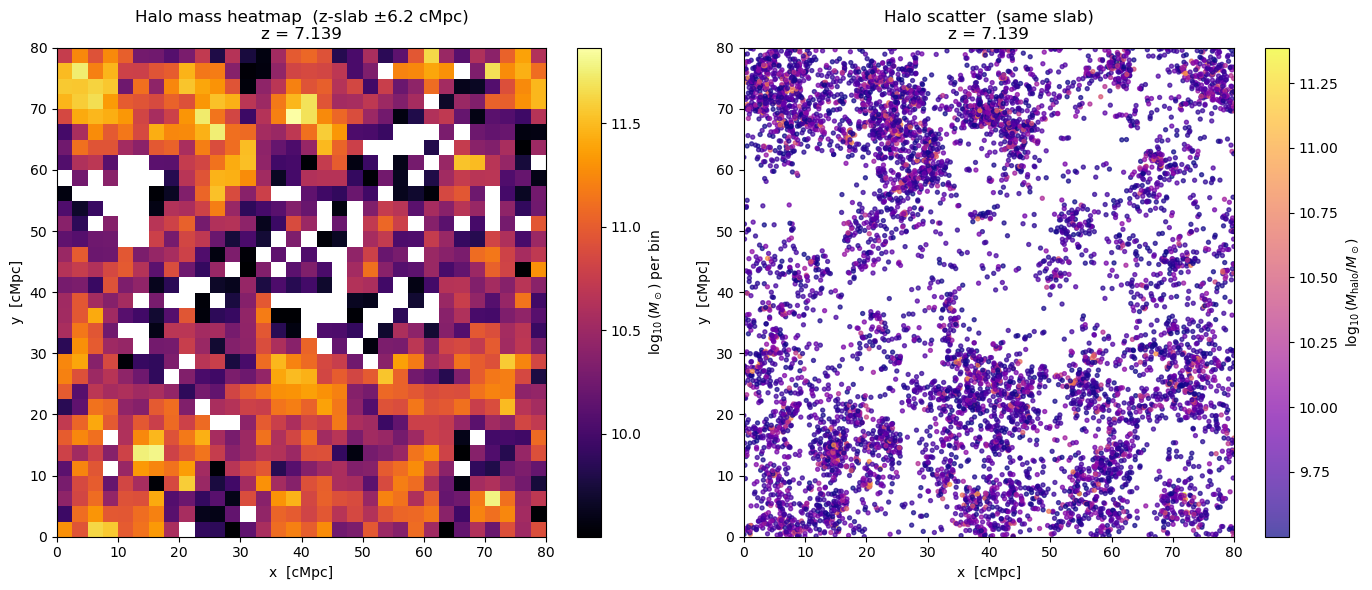

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ── load ──────────────────────────────────────────────────────────────────────
out_dir = os.path.join("Test_Sim",
    f"seed1000_MTURN9.0_FESC-1.00_z{z:.2f}")

coords = np.load(os.path.join(out_dir, "halo_coords_grid_017.npy"))  # cMpc
masses = np.load(os.path.join(out_dir, "halo_masses_grid_017.npy"))

# ── slab selection in cMpc ───────────────────────────────────────────────────
cell              = BOX_LEN / HII_DIM          # 1.25 cMpc
slab_thickness    = 10 * cell                  # 10 cells worth in cMpc
z_centre_cMpc     = BOX_LEN / 2               # 40 cMpc

in_slab = np.abs(coords[:, 2] - z_centre_cMpc) <= slab_thickness / 2

x_phys = coords[in_slab, 0]   # already cMpc
y_phys = coords[in_slab, 1]
m_h    = masses[in_slab]

print(f"Halos in slab: {in_slab.sum()}  (total: {len(masses)})")

# ── plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- LEFT: mass-weighted heatmap ---
bins = 32
h, xedges, yedges = np.histogram2d(
    x_phys, y_phys,
    bins=bins,
    range=[[0, BOX_LEN], [0, BOX_LEN]],
    weights=m_h
)
h[h == 0] = np.nan

im = axes[0].imshow(
    np.log10(h.T),
    origin="lower",
    extent=[0, BOX_LEN, 0, BOX_LEN],
    cmap="inferno",
    interpolation="nearest"
)
plt.colorbar(im, ax=axes[0], label=r"$\log_{10}(M_\odot)$ per bin")
axes[0].set_title(f"Halo mass heatmap  (z-slab ±{slab_thickness/2:.1f} cMpc)\nz = {z:.3f}")
axes[0].set_xlabel("x  [cMpc]")
axes[0].set_ylabel("y  [cMpc]")

# --- RIGHT: scatter ---
sc = axes[1].scatter(
    x_phys, y_phys,
    c=np.log10(m_h),
    s=8,
    cmap="plasma",
    alpha=0.7
)
plt.colorbar(sc, ax=axes[1], label=r"$\log_{10}(M_\mathrm{halo}/M_\odot)$")
axes[1].set_title(f"Halo scatter  (same slab)\nz = {z:.3f}")
axes[1].set_xlabel("x  [cMpc]")
axes[1].set_ylabel("y  [cMpc]")
axes[1].set_xlim(0, BOX_LEN)
axes[1].set_ylim(0, BOX_LEN)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, "halo_mass_heatmap_xy.png"), dpi=150)
plt.show()

coords min/max : 0.000 – 79.999 cMpc
density shape  : (64, 64, 64)
Total halos    : 50291
Most populated z-cell : 54  (959 halos)
Halos in slab ±0.62 cMpc : 961
Mass range     : 3.166e+09 – 5.738e+11 M_sun
log10(M) range : 9.50 – 11.76


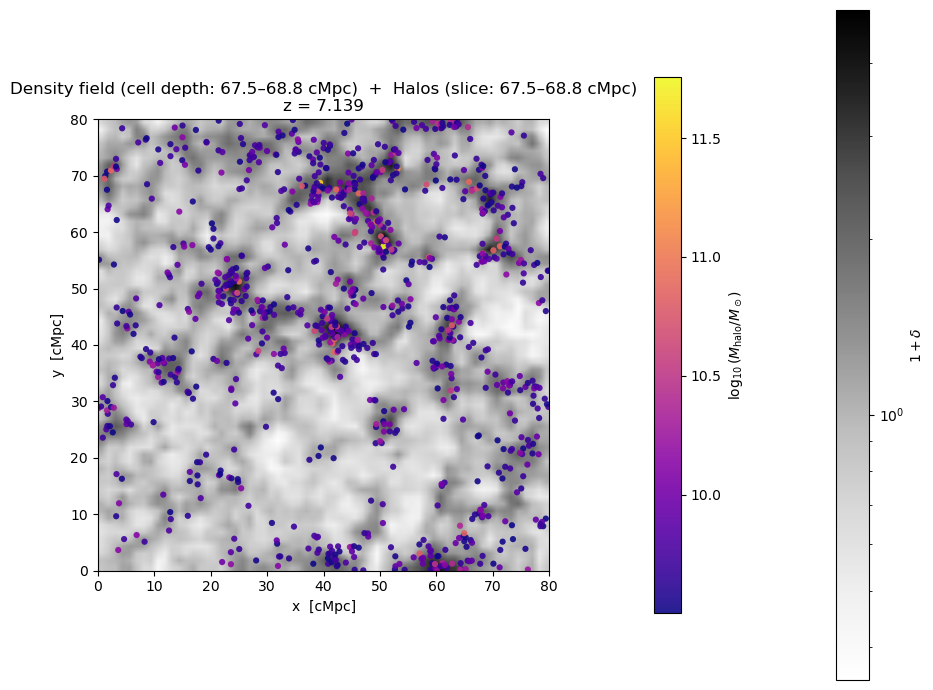

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ── load ──────────────────────────────────────────────────────────────────────
out_dir = os.path.join("Test_Sim",
    f"seed1000_MTURN9.0_FESC-1.00_z{z:.2f}")

coords  = np.load(os.path.join(out_dir, "halo_coords_grid_017.npy"))  # cMpc
masses  = np.load(os.path.join(out_dir, "halo_masses_grid_017.npy"))
density = np.load(os.path.join(out_dir, "density_grid_017.npy"))      # (64,64,64)

HII_DIM = density.shape[0]          # 64
cell    = BOX_LEN / HII_DIM         # 1.25 cMpc per cell

print(f"coords min/max : {coords.min():.3f} – {coords.max():.3f} cMpc")
print(f"density shape  : {density.shape}")
print(f"Total halos    : {len(masses)}")

# ── pick z-slice: find which density cell has most halos ─────────────────────
z_cells      = (coords[:, 2] / cell).astype(int).clip(0, HII_DIM - 1)
z_vals, z_counts = np.unique(z_cells, return_counts=True)
z_centre_cell = int(z_vals[np.argmax(z_counts)])   # density grid index
z_centre_cMpc = (z_centre_cell + 0.5) * cell       # centre of that cell
print(f"Most populated z-cell : {z_centre_cell}  ({z_counts.max()} halos)")

# ── slab selection in cMpc ───────────────────────────────────────────────────
slab_half_cMpc = 0.5 * cell    # ±half a cell (single slice); increase as needed
in_slice = np.abs(coords[:, 2] - z_centre_cMpc) <= slab_half_cMpc
print(f"Halos in slab ±{slab_half_cMpc:.2f} cMpc : {in_slice.sum()}")

# ── positions already in cMpc — use directly ─────────────────────────────────
x_h = coords[in_slice, 0]
y_h = coords[in_slice, 1]
m_h = masses[in_slice]

print(f"Mass range     : {m_h.min():.3e} – {m_h.max():.3e} M_sun")
print(f"log10(M) range : {np.log10(m_h).min():.2f} – {np.log10(m_h).max():.2f}")

# ── density slice ─────────────────────────────────────────────────────────────
dens_slice = density[:, :, z_centre_cell].T   # (HII_DIM, HII_DIM)

# ── plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(
    1 + dens_slice,
    origin="lower",
    extent=[0, BOX_LEN, 0, BOX_LEN],
    cmap="Greys",
    norm=plt.matplotlib.colors.LogNorm(),
    interpolation="bilinear"
)
cb1 = plt.colorbar(im, ax=ax, label=r"$1 + \delta$", fraction=0.046, pad=0.2)

sc = ax.scatter(
    x_h, y_h,
    c=np.log10(m_h),
    s=20,
    cmap="plasma",
    alpha=0.9,
    edgecolors="none"
)
cb2 = plt.colorbar(sc, ax=ax,
    label=r"$\log_{10}(M_\mathrm{halo}/M_\odot)$",
    fraction=0.046, pad=0.18)

z_lo = z_centre_cMpc - slab_half_cMpc
z_hi = z_centre_cMpc + slab_half_cMpc

ax.set_title(
    f"Density field (cell depth: {z_centre_cell*cell:.1f}–{(z_centre_cell+1)*cell:.1f} cMpc)  "
    f"+  Halos (slice: {z_lo:.1f}–{z_hi:.1f} cMpc)\n"
    f"z = {z:.3f}"
)
ax.set_xlabel("x  [cMpc]")
ax.set_ylabel("y  [cMpc]")
ax.set_xlim(0, BOX_LEN)
ax.set_ylim(0, BOX_LEN)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, "density_halos_xy.png"), dpi=150, bbox_inches="tight")
plt.show()

Halo map shape : (64, 64)
Total halos    : 50291
Map sum        : 50291  (should equal total halos)
Min/max counts : 0 – 46


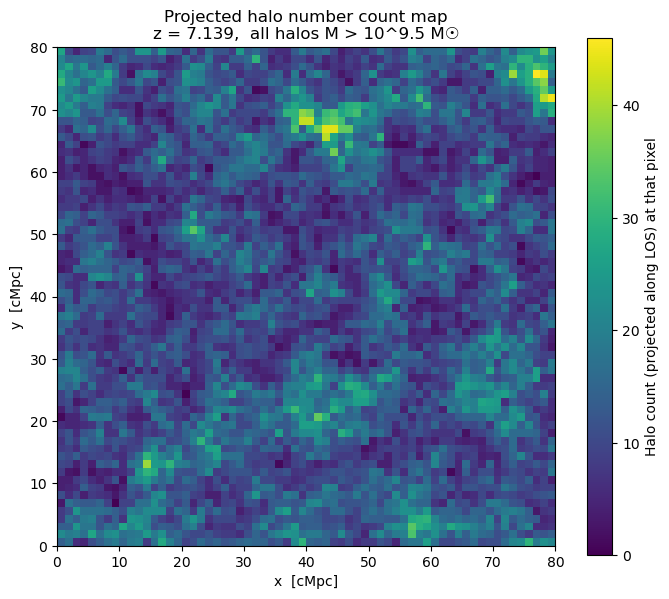

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# ── load halos ────────────────────────────────────────────────────────────────
coords = np.load(os.path.join(out_dir, "halo_coords_grid_017.npy"))  # cMpc, shape (N,3)
masses = np.load(os.path.join(out_dir, "halo_masses_grid_017.npy"))

# ── project along LOS (z-axis) → 2D number count map ────────────────────────
# Use same resolution as density grid: HII_DIM x HII_DIM pixels
n_pix = HII_DIM   # 64 pixels, change to match kSZ map resolution if needed

halo_map, xedges, yedges = np.histogram2d(
    coords[:, 0],   # x in cMpc
    coords[:, 1],   # y in cMpc
    bins=n_pix,
    range=[[0, BOX_LEN], [0, BOX_LEN]]
)
halo_map = halo_map.T   # transpose to match imshow convention

print(f"Halo map shape : {halo_map.shape}")
print(f"Total halos    : {coords.shape[0]}")
print(f"Map sum        : {halo_map.sum():.0f}  (should equal total halos)")
print(f"Min/max counts : {halo_map.min():.0f} – {halo_map.max():.0f}")

# ── plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(
    halo_map,
    origin="lower",
    extent=[0, BOX_LEN, 0, BOX_LEN],
    cmap="viridis",
    interpolation="nearest"
)
plt.colorbar(im, ax=ax, label="Halo count (projected along LOS) at that pixel")
ax.set_title(f"Projected halo number count map\nz = {z:.3f},  all halos M > 10^9.5 M☉")
ax.set_xlabel("x  [cMpc]")
ax.set_ylabel("y  [cMpc]")

plt.tight_layout()
plt.savefig(os.path.join(out_dir, "halo_number_map.png"), dpi=150)
plt.show()

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
True Halo Lightcone Builder — with caching
- Skips slices already computed (crash-safe)
- BOX_LEN=200 cMpc, HII_DIM=128
- Native zlist spacing z=15 to z=5
"""

import os
import gc
import time
import numpy as np
import py21cmfast as p21c
from py21cmfast import InputParameters
from astropy.cosmology import FlatLambdaCDM

os.environ["OMP_NUM_THREADS"] = "8"
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

# =============================================================================
# SETTINGS
# =============================================================================
BOX_LEN  = 200.0
HII_DIM  = 128
DIM      = 256
N_PIX    = HII_DIM
seed     = 1000
MASS_CUT = 10.0**8.5

cosmo = FlatLambdaCDM(H0=67.8, Om0=0.308)

zlist = [
    40.000000, 28.899476, 23.153921, 19.553736, 17.050835, 15.192528,
    13.748622, 12.58864,  11.632645, 10.828694, 10.14145,  9.545964,
     9.024079,  8.562235,  8.150086,  7.77959,   7.444391,  7.139393,
     6.860463,  6.604205,  6.367804,  6.148904,  5.945518,  5.755954,
     5.578765,  5.412706,  5.256697,  5.109794,  4.971176
]

z_lc = [z for z in zlist if 5.0 <= z <= 15.0]
chi  = np.array([cosmo.comoving_distance(z).value for z in z_lc])
dchi = np.abs(np.diff(chi))
dchi = np.append(dchi, dchi[-1])

# =============================================================================
# OUTPUT DIRECTORIES
# =============================================================================
OUT_DIR = "Halo_Lightcone_True"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "slices"),     exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "catalogues"), exist_ok=True)

# =============================================================================
# CACHE CHECK HELPER
# =============================================================================
def slice_is_cached(tag: str) -> bool:
    """Return True if all output files for this slice already exist."""
    files = [
        os.path.join(OUT_DIR, "slices",     f"massmap_{tag}.npy"),
        os.path.join(OUT_DIR, "catalogues", f"coords_{tag}.npy"),
        os.path.join(OUT_DIR, "catalogues", f"masses_{tag}.npy"),
    ]
    return all(os.path.exists(f) for f in files)

# =============================================================================
# FIXED PARAMETERS
# =============================================================================
cosmo_params = {
    "SIGMA_8": 0.829, "hlittle": 0.678, "OMm": 0.308,
    "OMb": 0.0482, "POWER_INDEX": 0.961, "OMn": 0.0,
    "OMk": 0.0, "OMr": 8.6e-05, "OMtot": 1.0, "Y_He": 0.24, "wl": -1.0
}
matter_options = {
    "HMF": "ST", "USE_RELATIVE_VELOCITIES": False,
    "POWER_SPECTRUM": "EH", "FILTER": "spherical-tophat",
    "HALO_FILTER": "spherical-tophat", "DEXM_OPTIMIZE": True,
    "SMOOTH_EVOLVED_DENSITY_FIELD": True,
    "USE_INTERPOLATION_TABLES": "hmf-interpolation",
    "USE_FFTW_WISDOM": True, "USE_HALO_FIELD": True,
    "KEEP_3D_VELOCITIES": False
}
simulation_options = {
    "BOX_LEN": BOX_LEN, "HII_DIM": HII_DIM, "DIM": DIM,
    "N_THREADS": 1, "SAMPLER_MIN_MASS": 8e7,
    "INITIAL_REDSHIFT": 300.0, "Z_HEAT_MAX": 35.0,
    "ZPRIME_STEP_FACTOR": 1.02,
}
astro_options = {
    "USE_MINI_HALOS": False, "INHOMO_RECO": True,
    "USE_TS_FLUCT": True, "USE_MASS_DEPENDENT_ZETA": True,
    "CELL_RECOMB": True, "PHOTON_CONS_TYPE": "no-photoncons",
    "USE_EXP_FILTER": True, "AVG_BELOW_SAMPLER": True,
    "HII_FILTER": "spherical-tophat", "HEAT_FILTER": "spherical-tophat"
}
astro_params = {
    "HII_EFF_FACTOR": 10.0, "F_STAR10": -1.1, "ALPHA_STAR": 0.5,
    "F_ESC10": -1.0, "ALPHA_ESC": -0.5, "M_TURN": 9.0,
    "ION_Tvir_MIN": 4.69897, "L_X": 40.5, "R_BUBBLE_MAX": 50.0,
    "R_BUBBLE_MIN": 0.6, "CLUMPING_FACTOR": 2.0, "ALPHA_UVB": 5.0
}

# =============================================================================
# CHECK CACHE STATUS BEFORE DOING ANYTHING EXPENSIVE
# =============================================================================
tags         = [f"z{z:.4f}" for z in z_lc]
cached       = [slice_is_cached(tag) for tag in tags]
n_cached     = sum(cached)
n_todo       = len(z_lc) - n_cached

print(f"Slices total     : {len(z_lc)}")
print(f"Already cached   : {n_cached}")
print(f"To compute       : {n_todo}")

# if everything is cached, skip initial conditions entirely
need_init = n_todo > 0

# =============================================================================
# INITIAL CONDITIONS (only if needed)
# =============================================================================
if need_init:
    inputs = InputParameters(
        random_seed=seed,
        cosmo_params=cosmo_params,
        matter_options=matter_options,
        simulation_options=simulation_options,
        astro_options=astro_options,
        astro_params=astro_params,
        node_redshifts=zlist
    )
    print("\nComputing initial conditions...")
    t0 = time.time()
    init_box = p21c.compute_initial_conditions(inputs=inputs)
    print(f"Done in {time.time()-t0:.1f} sec\n")
else:
    print("\nAll slices cached — skipping initial conditions entirely.")
    init_box = None
    inputs   = None

# =============================================================================
# LIGHTCONE LOOP
# =============================================================================
stacked_map = np.zeros((N_PIX, N_PIX), dtype=np.float64)
halo_counts = []
slice_times = []
metadata    = []

print(f"\nBuilding true halo lightcone over {len(z_lc)} slices...")
print("=" * 70)

for i, (z_slice, slab_thickness, tag) in enumerate(zip(z_lc, dchi, tags)):

    flip    = (i % 2 == 1)
    slab_lo = 0.0            if not flip else BOX_LEN - slab_thickness
    slab_hi = slab_thickness if not flip else BOX_LEN

    # ── CACHE HIT: load from disk ─────────────────────────────────────────
    if cached[i]:
        slice_map = np.load(os.path.join(OUT_DIR, "slices",     f"massmap_{tag}.npy"))
        masses    = np.load(os.path.join(OUT_DIR, "catalogues", f"masses_{tag}.npy"))
        n_halos   = len(masses)

        stacked_map += slice_map
        halo_counts.append(n_halos)

        print(f"  [{i+1:2d}/{len(z_lc)}] z={z_slice:.3f}  "
              f"slab={slab_lo:.1f}–{slab_hi:.1f}  "
              f"({'flipped' if flip else 'normal ':7s})  "
              f"halos={n_halos:5d}  [CACHED]")

        metadata.append({
            "index": i, "z": z_slice, "chi_cMpc": chi[i],
            "slab_lo_cMpc": slab_lo, "slab_hi_cMpc": slab_hi,
            "slab_thickness": slab_thickness, "flipped": flip,
            "n_halos": n_halos, "cached": True
        })
        del slice_map, masses
        continue

    # ── CACHE MISS: compute ───────────────────────────────────────────────
    t_slice = time.time()
    print(f"  [{i+1:2d}/{len(z_lc)}] z={z_slice:.3f}  "
          f"slab={slab_lo:.1f}–{slab_hi:.1f}  "
          f"({'flipped' if flip else 'normal ':7s})", end="  ", flush=True)

    halolist = p21c.determine_halo_list(
        redshift=float(z_slice),
        initial_conditions=init_box,
        inputs=inputs
    )

    masses = halolist.get("halo_masses")
    coords = halolist.get("halo_coords")

    # mass cut
    mask   = masses > MASS_CUT
    coords = coords[mask]
    masses = masses[mask]

    # LOS slab selection
    in_slab = (coords[:, 2] >= slab_lo) & (coords[:, 2] < slab_hi)
    coords  = coords[in_slab]
    masses  = masses[in_slab]
    n_halos = len(masses)
    halo_counts.append(n_halos)

    # save catalogue
    np.save(os.path.join(OUT_DIR, "catalogues", f"coords_{tag}.npy"), coords)
    np.save(os.path.join(OUT_DIR, "catalogues", f"masses_{tag}.npy"), masses)

    # 2D mass map
    if n_halos > 0:
        slice_map, _, _ = np.histogram2d(
            coords[:, 0], coords[:, 1],
            bins=N_PIX,
            range=[[0, BOX_LEN], [0, BOX_LEN]],
            weights=masses
        )
    else:
        slice_map = np.zeros((N_PIX, N_PIX))

    np.save(os.path.join(OUT_DIR, "slices", f"massmap_{tag}.npy"), slice_map)
    stacked_map += slice_map

    dt = time.time() - t_slice
    slice_times.append(dt)
    # ETA only from non-cached slices remaining
    n_remaining = sum(1 for j, c in enumerate(cached) if j > i and not c)
    eta = np.mean(slice_times) * n_remaining if slice_times else 0

    print(f"halos={n_halos:5d}  t={dt:.1f}s  ETA={eta/60:.1f}min")

    metadata.append({
        "index": i, "z": z_slice, "chi_cMpc": chi[i],
        "slab_lo_cMpc": slab_lo, "slab_hi_cMpc": slab_hi,
        "slab_thickness": slab_thickness, "flipped": flip,
        "n_halos": n_halos, "cached": False
    })

    del halolist, masses, coords, slice_map, in_slab
    gc.collect()

# =============================================================================
# SAVE FINAL STACKED MAP + METADATA
# =============================================================================
np.save(os.path.join(OUT_DIR, "stacked_mass_map.npy"), stacked_map)
np.save(os.path.join(OUT_DIR, "z_lc.npy"),             np.array(z_lc))
np.save(os.path.join(OUT_DIR, "chi_lc.npy"),           chi)
np.save(os.path.join(OUT_DIR, "dchi_lc.npy"),          dchi)
np.save(os.path.join(OUT_DIR, "halo_counts.npy"),      np.array(halo_counts))

with open(os.path.join(OUT_DIR, "metadata.txt"), "w") as f:
    f.write(f"True Halo Lightcone Metadata\n")
    f.write(f"BOX_LEN  = {BOX_LEN} cMpc\n")
    f.write(f"HII_DIM  = {HII_DIM}\n")
    f.write(f"MASS_CUT = 10^{np.log10(MASS_CUT):.1f} M_sun\n")
    f.write(f"seed     = {seed}\n\n")
    f.write(f"{'i':>3}  {'z':>8}  {'chi':>10}  {'slab_lo':>8}  "
            f"{'slab_hi':>8}  {'dchi':>8}  {'flip':>6}  "
            f"{'n_halos':>8}  {'cached':>8}\n")
    f.write("-" * 75 + "\n")
    for m in metadata:
        f.write(
            f"{m['index']:3d}  {m['z']:8.3f}  {m['chi_cMpc']:10.1f}  "
            f"{m['slab_lo_cMpc']:8.1f}  {m['slab_hi_cMpc']:8.1f}  "
            f"{m['slab_thickness']:8.1f}  {str(m['flipped']):>6}  "
            f"{m['n_halos']:8d}  {str(m['cached']):>8}\n"
        )

total_time = sum(slice_times)
print("\n" + "=" * 70)
print(f"Lightcone complete!")
print(f"Slices computed  : {len(slice_times)}  (cached: {n_cached})")
print(f"Total halos      : {sum(halo_counts):,}")
print(f"Stacked map      : {stacked_map.shape}")
print(f"Compute time     : {total_time/60:.1f} min  (cached slices free)")
print(f"Saved to         : {OUT_DIR}/")

Slices total     : 22
Already cached   : 0
To compute       : 22

Computing initial conditions...
Done in 80.3 sec


Building true halo lightcone over 22 slices...
  [ 1/22] z=13.749  slab=0.0–173.4  (normal )  halos=499707  t=4.5s  ETA=1.6min
  [ 2/22] z=12.589  slab=39.5–200.0  (flipped)  halos=955268  t=6.3s  ETA=1.8min
  [ 3/22] z=11.633  slab=0.0–149.8  (normal )  halos=1551912  t=8.5s  ETA=2.0min
  [ 4/22] z=10.829  slab=59.3–200.0  (flipped)  halos=2219034  t=10.0s  ETA=2.2min
  [ 5/22] z=10.141  slab=0.0–132.8  (normal )  halos=2952462  t=12.8s  ETA=2.4min
  [ 6/22] z=9.546  slab=74.0–200.0  (flipped)  halos=3680217  t=14.7s  ETA=2.5min
  [ 7/22] z=9.024  slab=0.0–120.0  (normal )  halos=4391504  t=15.7s  ETA=2.6min
  [ 8/22] z=8.562  slab=85.4–200.0  (flipped)  halos=5051243  t=17.7s  ETA=2.6min
  [ 9/22] z=8.150  slab=0.0–109.8  (normal )  halos=5712617  t=20.4s  ETA=2.7min
  [10/22] z=7.780  slab=94.5–200.0  (flipped)  halos=6226537  t=22.7s  ETA=2.7min
  [11/22] z=7.444  sl

Total points to plot : 660  (22 slices × 30)
log10(M) range       : 10.28 – 12.92


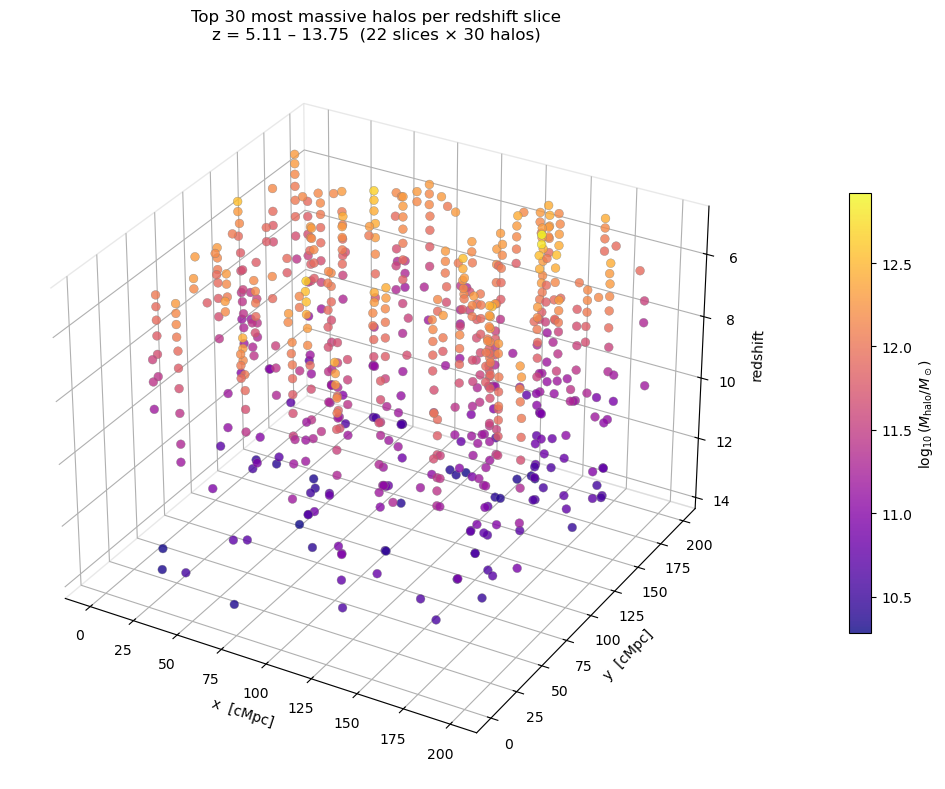

Saved: Halo_Lightcone_True/top30_per_slice_3D.png


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

OUT_DIR = "Halo_Lightcone_True"
z_lc    = np.load(os.path.join(OUT_DIR, "z_lc.npy"))

# ── load top 30 per slice ─────────────────────────────────────────────────────
top_coords_all = []
top_masses_all = []
top_z_all      = []

for z_slice in z_lc:
    tag    = f"z{z_slice:.4f}"
    coords = np.load(os.path.join(OUT_DIR, "catalogues", f"coords_{tag}.npy"))
    masses = np.load(os.path.join(OUT_DIR, "catalogues", f"masses_{tag}.npy"))

    if len(masses) == 0:
        continue

    # top 30 in this slice
    n_top  = min(30, len(masses))
    top_idx = np.argsort(masses)[-n_top:][::-1]

    top_coords_all.append(coords[top_idx])
    top_masses_all.append(masses[top_idx])
    top_z_all.append(np.full(n_top, z_slice))

top_coords = np.concatenate(top_coords_all, axis=0)
top_masses = np.concatenate(top_masses_all, axis=0)
top_z      = np.concatenate(top_z_all,      axis=0)

print(f"Total points to plot : {len(top_masses)}  ({len(z_lc)} slices × 30)")
print(f"log10(M) range       : {np.log10(top_masses.min()):.2f} – "
      f"{np.log10(top_masses.max()):.2f}")

# ── 3D plot ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(11, 8))
ax  = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    top_coords[:, 0],   # x [cMpc]
    top_coords[:, 1],   # y [cMpc]
    top_z,              # redshift as LOS axis
    c=np.log10(top_masses),
    cmap="plasma",
    s=40,
    alpha=0.8,
    edgecolors="grey",
    linewidths=0.3,
    depthshade=True
)

cb = plt.colorbar(sc, ax=ax, pad=0.1, shrink=0.6)
cb.set_label(r"$\log_{10}(M_\mathrm{halo}/M_\odot)$", color="black")
cb.ax.yaxis.set_tick_params(color="black")
plt.setp(cb.ax.yaxis.get_ticklabels(), color="black")

ax.set_xlabel("x  [cMpc]")
ax.set_ylabel("y  [cMpc]")
ax.set_zlabel("redshift")
ax.invert_zaxis()   # low z (close) at top, high z (far) at bottom
ax.set_title(f"Top 30 most massive halos per redshift slice\n"
             f"z = {z_lc[-1]:.2f} – {z_lc[0]:.2f}  "
             f"({len(z_lc)} slices × 30 halos)")

# ── white background ──────────────────────────────────────────────────────────
ax.set_facecolor("white")
fig.patch.set_facecolor("white")
ax.tick_params(colors="black")
ax.xaxis.label.set_color("black")
ax.yaxis.label.set_color("black")
ax.zaxis.label.set_color("black")
ax.title.set_color("black")
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor("lightgrey")
ax.yaxis.pane.set_edgecolor("lightgrey")
ax.zaxis.pane.set_edgecolor("lightgrey")
ax.grid(True, color="lightgrey", linewidth=0.5)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "top30_per_slice_3D.png"),
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: Halo_Lightcone_True/top30_per_slice_3D.png")

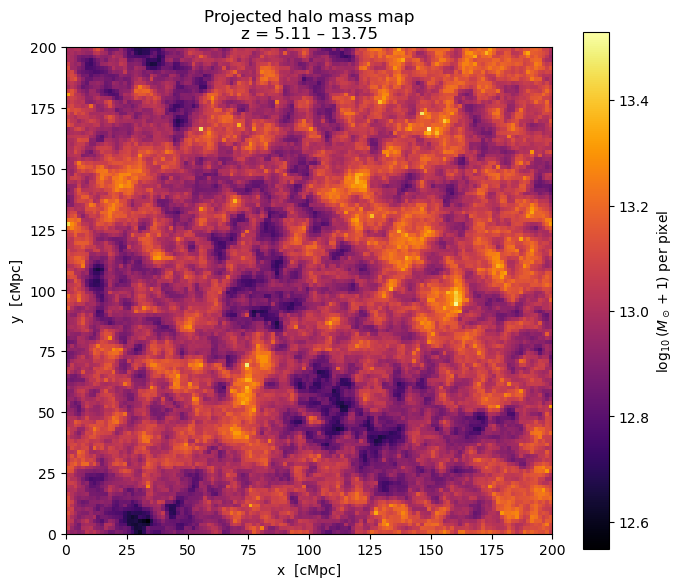

Saved: Halo_Lightcone_True/projected_mass_map.png


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os

OUT_DIR = "Halo_Lightcone_True"
BOX_LEN = 200.0
HII_DIM = 128
N_PIX   = HII_DIM

z_lc = np.load(os.path.join(OUT_DIR, "z_lc.npy"))

# ── build projected mass map ──────────────────────────────────────────────────
mass_map = np.zeros((N_PIX, N_PIX), dtype=np.float64)

for i, z_slice in enumerate(z_lc):
    tag    = f"z{z_slice:.4f}"
    coords = np.load(os.path.join(OUT_DIR, "catalogues", f"coords_{tag}.npy"))
    masses = np.load(os.path.join(OUT_DIR, "catalogues", f"masses_{tag}.npy"))

    if len(masses) == 0:
        continue

    slab_map, _, _ = np.histogram2d(
        coords[:, 0], coords[:, 1],
        bins=N_PIX,
        range=[[0, BOX_LEN], [0, BOX_LEN]],
        weights=masses
    )
    mass_map += slab_map.T
    del coords, masses, slab_map

np.save(os.path.join(OUT_DIR, "projected_mass_map.npy"), mass_map)

# ── plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(
    np.log10(mass_map + 1),
    origin="lower",
    extent=[0, BOX_LEN, 0, BOX_LEN],
    cmap="inferno",
    interpolation="nearest"
)
plt.colorbar(im, ax=ax, label=r"$\log_{10}(M_\odot + 1)$ per pixel")
ax.set_title(f"Projected halo mass map\nz = {z_lc[-1]:.2f} – {z_lc[0]:.2f}")
ax.set_xlabel("x  [cMpc]")
ax.set_ylabel("y  [cMpc]")

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "projected_mass_map.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_DIR}/projected_mass_map.png")

/home/swanith/miniconda3/envs/p21v4py311/lib/python3.11/site-packages/attr/_make.py:3040: UserWarning: You are setting R_BUBBLE_MAX != 50 when INHOMO_RECO=True. This is non-standard (but allowed), and usually occurs upon manual update of INHOMO_RECO
  v(inst, attr, value)


Nodes     : 65
z range   : 5.00 – 20.31
Cell size : 1.56 Mpc cMpc
BOX_LEN   : 100.0 cMpc
HII_DIM   : 64
✓ Monkey-patch applied

Running lightcone...

✓ Lightcone complete in 5.2 min
  brightness_temp           shape=(64, 64, 1905)
  density                   shape=(64, 64, 1905)
  neutral_fraction          shape=(64, 64, 1905)
  velocity_z                shape=(64, 64, 1905)
  n_ion                     shape=(64, 64, 1905)
  halo_sfr                  shape=(64, 64, 1905)
  kinetic_temperature       shape=(64, 64, 1905)
  tau_21                    shape=(64, 64, 1905)
  los_velocity              shape=(64, 64, 1905)
  z=10.085  z_cell=35  slab=[54.69, 56.25] cMpc  halos in slab: 7,892 / 539,824
  z=13.059  z_cell=57  slab=[89.06, 90.62] cMpc  halos in slab: 1,416 / 101,332
  z=17.187  z_cell=0  slab=[0.00, 1.56] cMpc  halos in slab: 81 / 4,642
  z=5.495  z_cell=62  slab=[96.88, 98.44] cMpc  halos in slab: 43,870 / 2,765,235
  z=7.401  z_cell=30  slab=[46.88, 48.44] cMpc  halos in slab: 

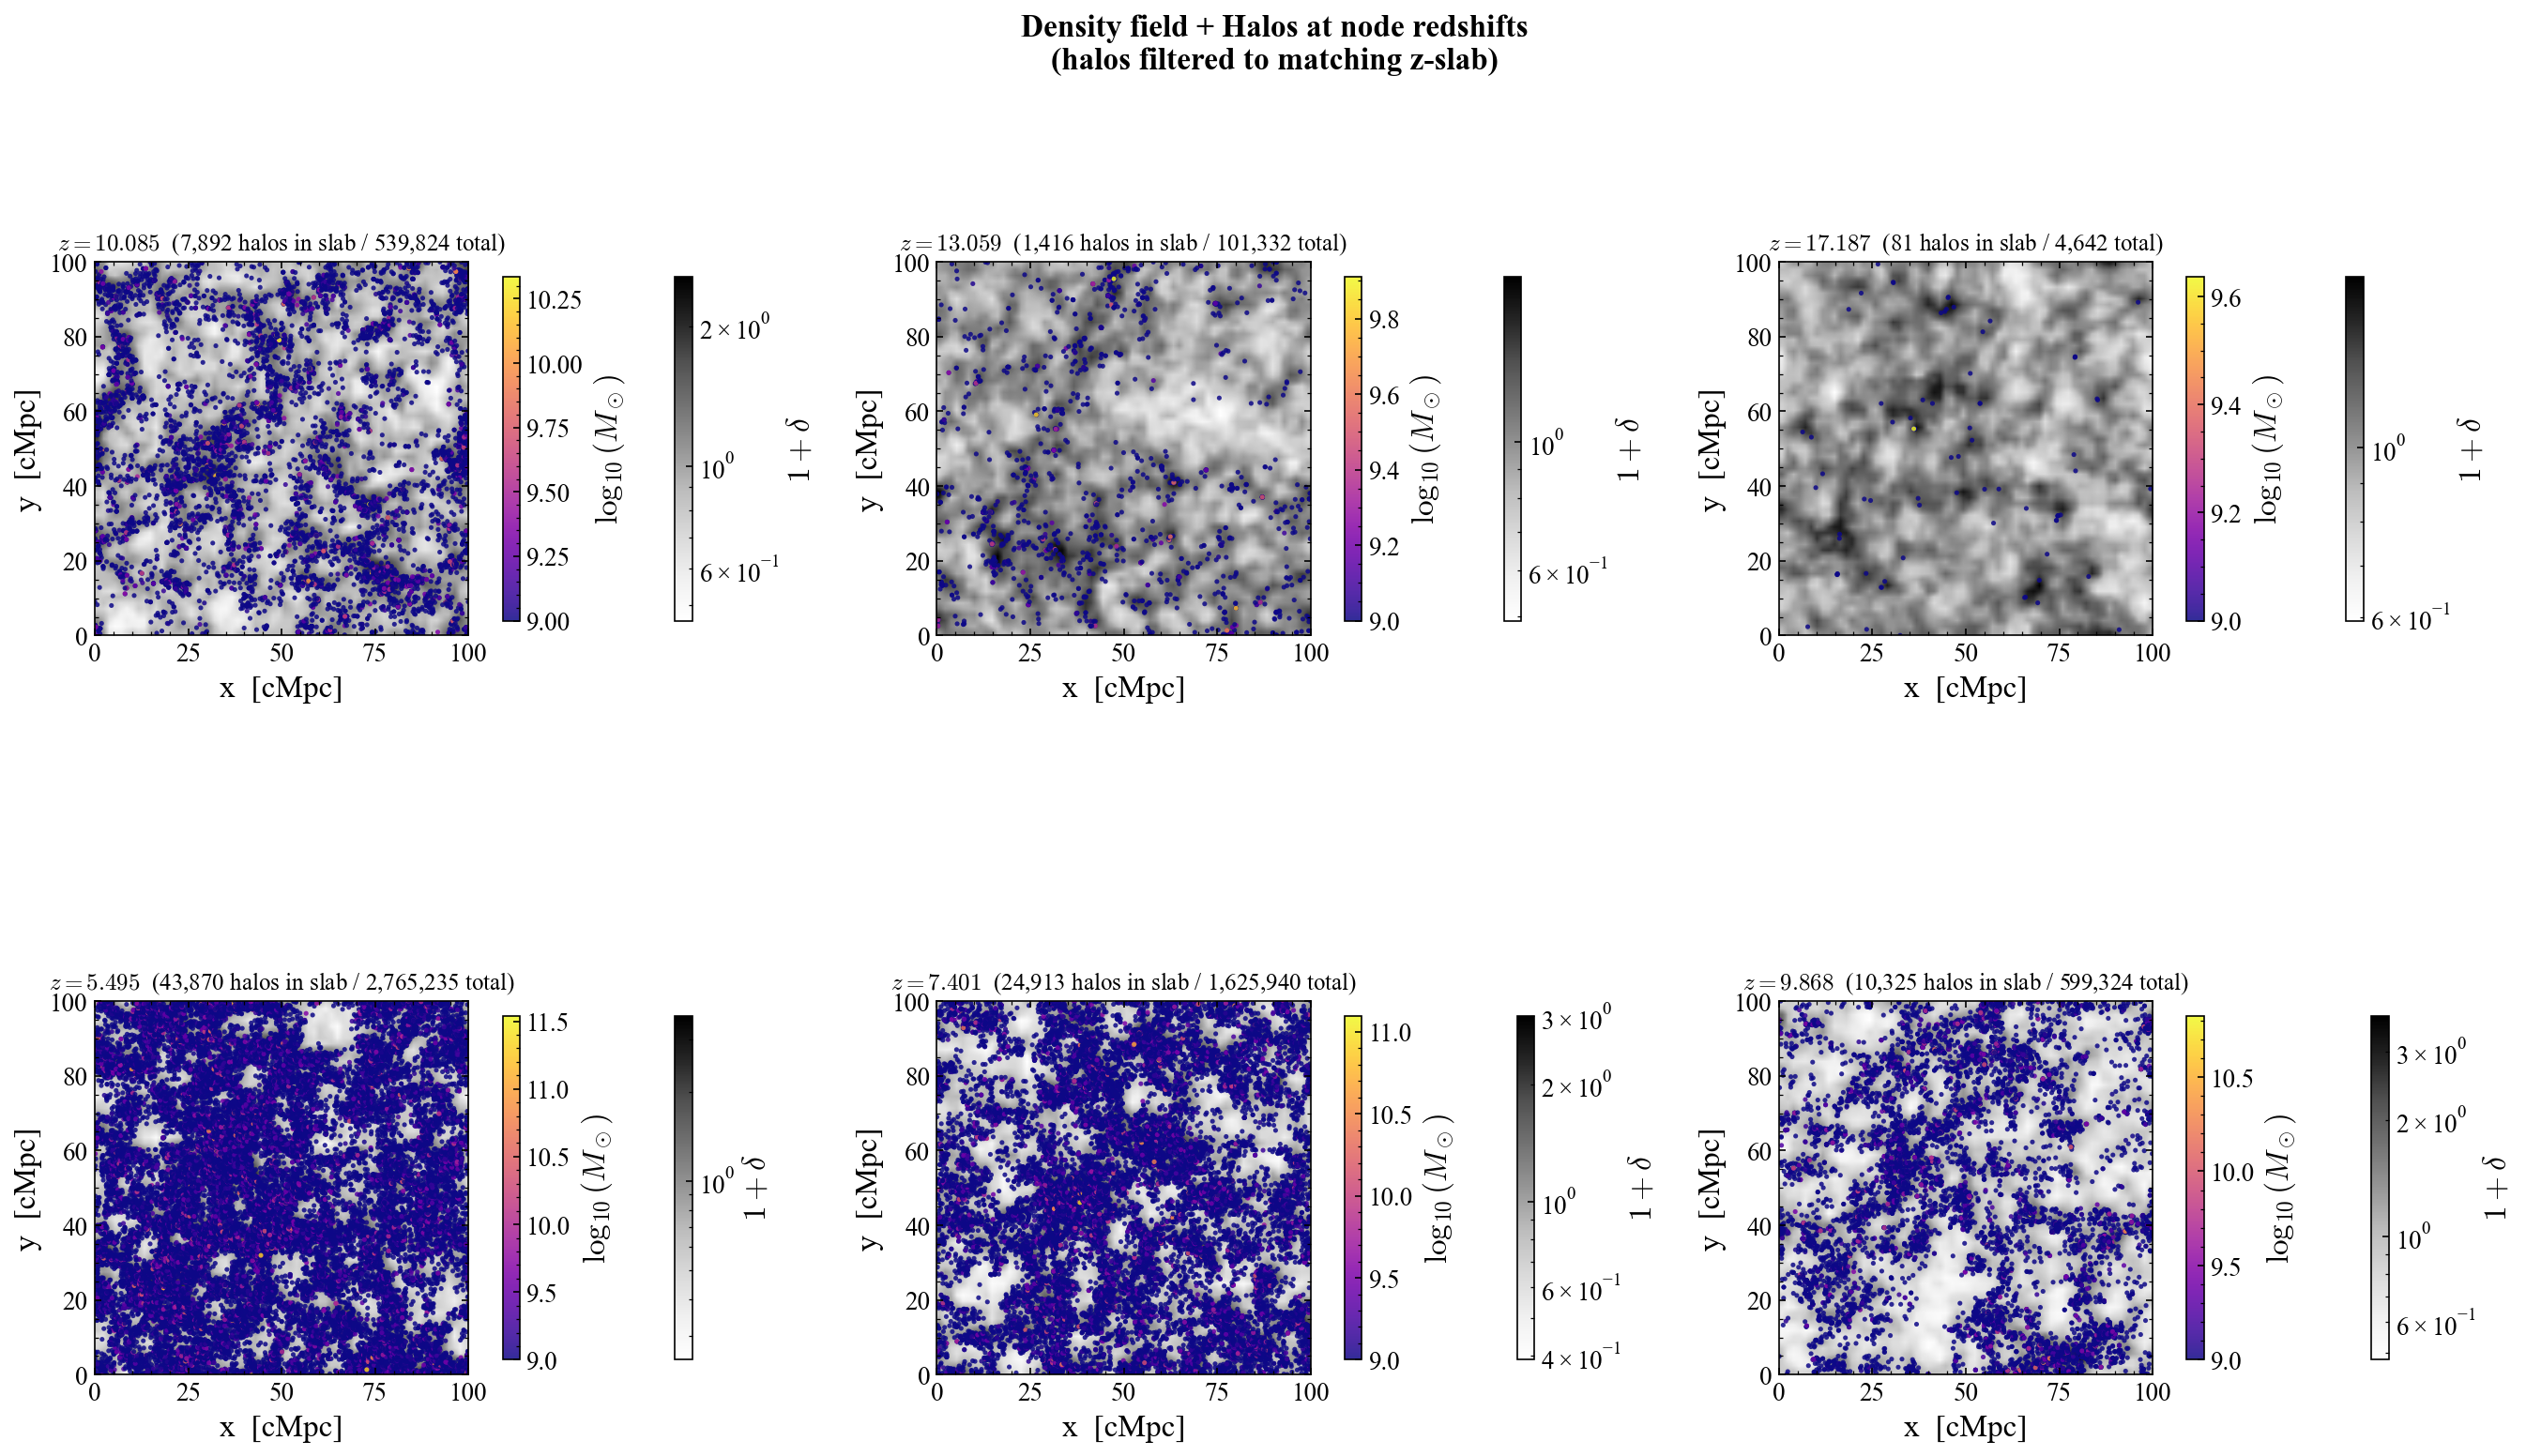

✓ Saved: density_halos_nodes.png / .pdf

✓ All plots saved to: /home/swanith/Desktop/Research/Semester 6/Plots/LAE_cross/lightcone_plots/


In [1]:
# =============================================================================
# FULL LIGHTCONE RUN + PLOTS (v4) with halo monkey-patch
# =============================================================================

import os
import time
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import py21cmfast as p21c
from py21cmfast.drivers import coeval as coeval_module
from py21cmfast.drivers.coeval import (
    _progressbar,
    _get_photon_nonconservation_data,
    Coeval,
)

# =============================================================================
# SETTINGS
# =============================================================================
PLOT_DIR = "lightcone_plots"
HALO_OUT = "lightcone_halos/catalogues"
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(HALO_OUT, exist_ok=True)

# =============================================================================
# INPUTS (v4 API)
# =============================================================================
inputs = p21c.InputParameters.from_template(
    'default',
    node_redshifts=p21c.get_logspaced_redshifts(
        min_redshift=5.0,
        max_redshift=20.0,
        z_step_factor=1.02,
    ),
    random_seed=37,
    HII_DIM=64,
    BOX_LEN=100.0,
    N_THREADS=16,
    Z_HEAT_MAX=20.0,
    KEEP_3D_VELOCITIES=True,
    USE_MASS_DEPENDENT_ZETA=True,
    INHOMO_RECO=True,
    USE_TS_FLUCT=True,
    SAMPLER_MIN_MASS=1e8,
    SAMPLER_BUFFER_FACTOR=2.0,
)

print(f"Nodes     : {len(inputs.node_redshifts)}")
print(f"z range   : {min(inputs.node_redshifts):.2f} – {max(inputs.node_redshifts):.2f}")
print(f"Cell size : {inputs.simulation_options.cell_size:.2f} cMpc")
print(f"BOX_LEN   : {inputs.simulation_options.BOX_LEN} cMpc")
print(f"HII_DIM   : {inputs.simulation_options.HII_DIM}")

# =============================================================================
# LIGHTCONER
# =============================================================================
lightconer = p21c.RectilinearLightconer.between_redshifts(
    min_redshift=min(inputs.node_redshifts) + 0.1,
    max_redshift=max(inputs.node_redshifts) - 0.1,
    quantities=(
        "brightness_temp",
        "density",
        "neutral_fraction",
        "velocity_z",
        "n_ion",
        "halo_sfr",
        "kinetic_temperature",   # ← add this line
    ),
    resolution=inputs.simulation_options.cell_size,
)

# =============================================================================
# MONKEY-PATCH: save halos before purge
# =============================================================================
def _redshift_loop_generator_patched(
    inputs, initial_conditions, all_redshifts, perturbed_field,
    pt_halos, write, iokw, cleanup, progressbar,
    photon_nonconservation_data, start_idx=0, init_coeval=None,
):
    from py21cmfast.io.caching import CacheConfig
    import py21cmfast.drivers.single_field as sf

    if isinstance(write, bool):
        write = CacheConfig()

    hbox_arr        = []
    prev_coeval     = init_coeval
    this_coeval     = None
    this_halobox    = None
    this_spin_temp  = None
    this_pthalo     = None
    this_xraysource = None

    kw = {**iokw, "initial_conditions": initial_conditions}

    with _progressbar(disable=not progressbar) as _progbar:
        for iz, z in _progbar.track(
            enumerate(all_redshifts),
            description="Evolving Astrophysics",
            total=len(all_redshifts),
        ):
            if iz < start_idx:
                continue

            this_perturbed_field = perturbed_field[iz]
            this_perturbed_field.load_all()

            if inputs.matter_options.USE_HALO_FIELD:
                if not inputs.matter_options.FIXED_HALO_GRIDS:
                    this_pthalo = pt_halos[iz]
                    this_pthalo.load_all()

                this_halobox = sf.compute_halo_grid(
                    inputs=inputs,
                    perturbed_halo_list=this_pthalo,
                    redshift=z,
                    previous_ionize_box=getattr(prev_coeval, "ionized_box", None),
                    previous_spin_temp=getattr(prev_coeval, "ts_box", None),
                    write=write.halobox,
                    **kw,
                )

            if inputs.astro_options.USE_TS_FLUCT:
                if inputs.matter_options.USE_HALO_FIELD:
                    this_xraysource = sf.compute_xray_source_field(
                        redshift=z,
                        hboxes=[*hbox_arr, this_halobox],
                        write=write.xray_source_box,
                        **kw,
                    )
                this_spin_temp = sf.compute_spin_temperature(
                    inputs=inputs,
                    previous_spin_temp=getattr(prev_coeval, "ts_box", None),
                    perturbed_field=this_perturbed_field,
                    xray_source_box=this_xraysource,
                    write=write.spin_temp,
                    **kw,
                    cleanup=(cleanup and z == all_redshifts[-1]),
                )
                if inputs.matter_options.USE_HALO_FIELD:
                    this_xraysource.purge(force=True)
                if inputs.matter_options.USE_HALO_FIELD:
                    this_xraysource.purge()

            this_ionized_box = sf.compute_ionization_field(
                inputs=inputs,
                previous_ionized_box=getattr(prev_coeval, "ionized_box", None),
                perturbed_field=this_perturbed_field,
                previous_perturbed_field=getattr(prev_coeval, "perturbed_field", None),
                halobox=this_halobox,
                spin_temp=this_spin_temp,
                write=write.ionized_box,
                **kw,
            )

            this_bt = sf.brightness_temperature(
                ionized_box=this_ionized_box,
                perturbed_field=this_perturbed_field,
                spin_temp=this_spin_temp,
                write=write.brightness_temp,
                **iokw,
            )

            if inputs.astro_options.PHOTON_CONS_TYPE == "z-photoncons":
                photon_nonconservation_data = _get_photon_nonconservation_data()

            this_coeval = Coeval(
                initial_conditions=initial_conditions,
                perturbed_field=this_perturbed_field,
                ionized_box=this_ionized_box,
                brightness_temperature=this_bt,
                ts_box=this_spin_temp,
                halobox=this_halobox,
                photon_nonconservation_data=photon_nonconservation_data,
            )

            if prev_coeval is not None:
                prev_coeval.perturbed_field.purge()
                if (
                    inputs.matter_options.USE_HALO_FIELD
                    and write.halobox
                    and iz + 1 < len(all_redshifts)
                ):
                    for hbox in hbox_arr:
                        hbox.prepare_for_next_snapshot(next_z=all_redshifts[iz + 1])

            # ── SAVE HALOS BEFORE PURGE ───────────────────────────────────────
            if this_pthalo is not None:
                try:
                    masses = this_pthalo.get("halo_masses")
                    coords = this_pthalo.get("halo_coords")   # cMpc
                    if masses is not None and coords is not None and len(masses) > 0:
                        mask = masses > 10.0**9.0
                        tag  = f"z{z:.4f}"
                        np.save(os.path.join(HALO_OUT, f"masses_{tag}.npy"), masses[mask])
                        np.save(os.path.join(HALO_OUT, f"coords_{tag}.npy"),  coords[mask])
                        print(f"  z={z:.3f}  halos={mask.sum():,}  "
                              f"log10M_max={np.log10(masses[mask].max()):.2f}")
                    else:
                        print(f"  z={z:.3f}  0 halos above threshold")
                except Exception as e:
                    print(f"  z={z:.3f}  halo save failed: {e}")
                this_pthalo.purge()
            # ─────────────────────────────────────────────────────────────────

            if z in inputs.node_redshifts:
                prev_coeval = this_coeval
                hbox_arr   += [this_halobox]

            yield iz, this_coeval

# apply patch
coeval_module._redshift_loop_generator = _redshift_loop_generator_patched
print("✓ Monkey-patch applied")

# =============================================================================
# RUN LIGHTCONE
# =============================================================================
t0 = time.time()
print("\nRunning lightcone...")

lightcone = p21c.run_lightcone(
    inputs=inputs,
    lightconer=lightconer,
    write=True,
)

dt = time.time() - t0
print(f"\n✓ Lightcone complete in {dt/60:.1f} min")
for k, v in lightcone.lightcones.items():
    print(f"  {k:25s} shape={v.shape}")

# =============================================================================
# PLOT STYLE
# =============================================================================
STYLE = {
    'font.family':           'serif',
    'font.serif':            ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset':      'cm',
    'font.size':             14,
    'axes.labelsize':        16,
    'axes.titlesize':        16,
    'xtick.labelsize':       13,
    'ytick.labelsize':       13,
    'xtick.direction':       'in',
    'ytick.direction':       'in',
    'xtick.top':             True,
    'ytick.right':           True,
    'xtick.minor.visible':   True,
    'ytick.minor.visible':   True,
    'figure.dpi':            150,
    'savefig.dpi':           300,
    'savefig.bbox':          'tight',
}

BOX_LEN  = inputs.simulation_options.BOX_LEN
HII_DIM  = inputs.simulation_options.HII_DIM
z_lc     = lightcone.lightcone_redshifts
cell_size_mpc = BOX_LEN / HII_DIM

# pre-compute lightcone distances in pixels once — reused per panel
lcpix = lightconer.get_lc_distances_in_pixels(inputs.simulation_options.cell_size)

# =============================================================================
# PLOT: DENSITY + HALOS AT NODE REDSHIFTS (slab-filtered)
# =============================================================================
halo_files  = sorted([f for f in os.listdir(HALO_OUT) if f.startswith('masses')])
node_z_list = [float(f.replace('masses_z', '').replace('.npy', ''))
               for f in halo_files]

if len(node_z_list) >= 6:
    idx_pick = np.linspace(0, len(node_z_list) - 1, 6, dtype=int)
else:
    idx_pick = np.arange(len(node_z_list))

z_pick = [node_z_list[i] for i in idx_pick]

with mpl.rc_context(STYLE):
    ncols = 3
    nrows = int(np.ceil(len(z_pick) / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(6 * ncols, 5.5 * nrows),
                             constrained_layout=True)
    axes = np.array(axes).flatten()

    for ax, z_node in zip(axes, z_pick):
        tag    = f"z{z_node:.4f}"
        masses = np.load(os.path.join(HALO_OUT, f"masses_{tag}.npy"))
        coords = np.load(os.path.join(HALO_OUT, f"coords_{tag}.npy"))

        # ── find the lightcone slice index closest to this redshift ───────────
        z_idx      = np.argmin(np.abs(z_lc - z_node))
        dens_slice = lightcone.lightcones['density'][:, :, z_idx].T

        # ── compute which z-cell of the raw box this slice samples ────────────
        from astropy.units import pixel
        lcidx  = int((lcpix.max() - lcpix[z_idx] + 1 * pixel).to_value(pixel))
        z_cell = (-lcidx + lightconer.index_offset) % HII_DIM
        z_lo   = z_cell * cell_size_mpc
        z_hi   = z_lo + cell_size_mpc

        # ── filter halos to the matching slab ────────────────────────────────
        depth_mask = (coords[:, 2] >= z_lo) & (coords[:, 2] < z_hi)
        m_slab     = masses[depth_mask]
        c_slab     = coords[depth_mask]

        print(f"  z={z_node:.3f}  z_cell={z_cell}  "
              f"slab=[{z_lo:.2f}, {z_hi:.2f}] cMpc  "
              f"halos in slab: {depth_mask.sum():,} / {len(masses):,}")

        # ── density background ────────────────────────────────────────────────
        im = ax.imshow(
            1 + dens_slice,
            origin='lower',
            extent=[0, BOX_LEN, 0, BOX_LEN],
            cmap='Greys',
            norm=mcolors.LogNorm(),
            interpolation='bilinear',
        )
        plt.colorbar(im, ax=ax, label=r'$1+\delta$',
                     fraction=0.046, pad=0.15)

        # ── halo scatter — only halos co-spatial with the density slice ───────
        if len(m_slab) > 0:
            sc = ax.scatter(
                c_slab[:, 0], c_slab[:, 1],
                c=np.log10(m_slab),
                s=6,
                cmap='plasma',
                alpha=0.85,
                edgecolors='none',
                vmin=9.0,
                vmax=np.log10(m_slab.max()),
            )
            plt.colorbar(sc, ax=ax,
                         label=r'$\log_{10}(M_\odot)$',
                         fraction=0.046, pad=0.04)

        ax.set_xlim(0, BOX_LEN)
        ax.set_ylim(0, BOX_LEN)
        ax.set_xlabel("x  [cMpc]")
        ax.set_ylabel("y  [cMpc]")
        ax.set_title(
            f"$z = {z_node:.3f}$  "
            f"({depth_mask.sum():,} halos in slab / {len(masses):,} total)",
            fontsize=12
        )

    for ax in axes[len(z_pick):]:
        ax.set_visible(False)

    fig.suptitle(
        "Density field + Halos at node redshifts\n"
        "(halos filtered to matching z-slab)",
        fontsize=16, fontweight='bold'
    )
    plt.savefig(os.path.join(PLOT_DIR, "density_halos_nodes.png"),
                dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(PLOT_DIR, "density_halos_nodes.pdf"),
                bbox_inches='tight')
    plt.show()
    print("✓ Saved: density_halos_nodes.png / .pdf")

print(f"\n✓ All plots saved to: {os.path.abspath(PLOT_DIR)}/")

rho_mean_0 = 3.9341e+10 M_sun/cMpc^3
Running CAMB...


/tmp/ipykernel_2196866/66058950.py:89: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  val, _ = quad(integrand, np.log(1e-4), np.log(1e4), limit=200)


σ8 raw = 0.8095, target = 0.8102, norm = 1.0008
Computing σ(R) grid...
Computing HMFs...


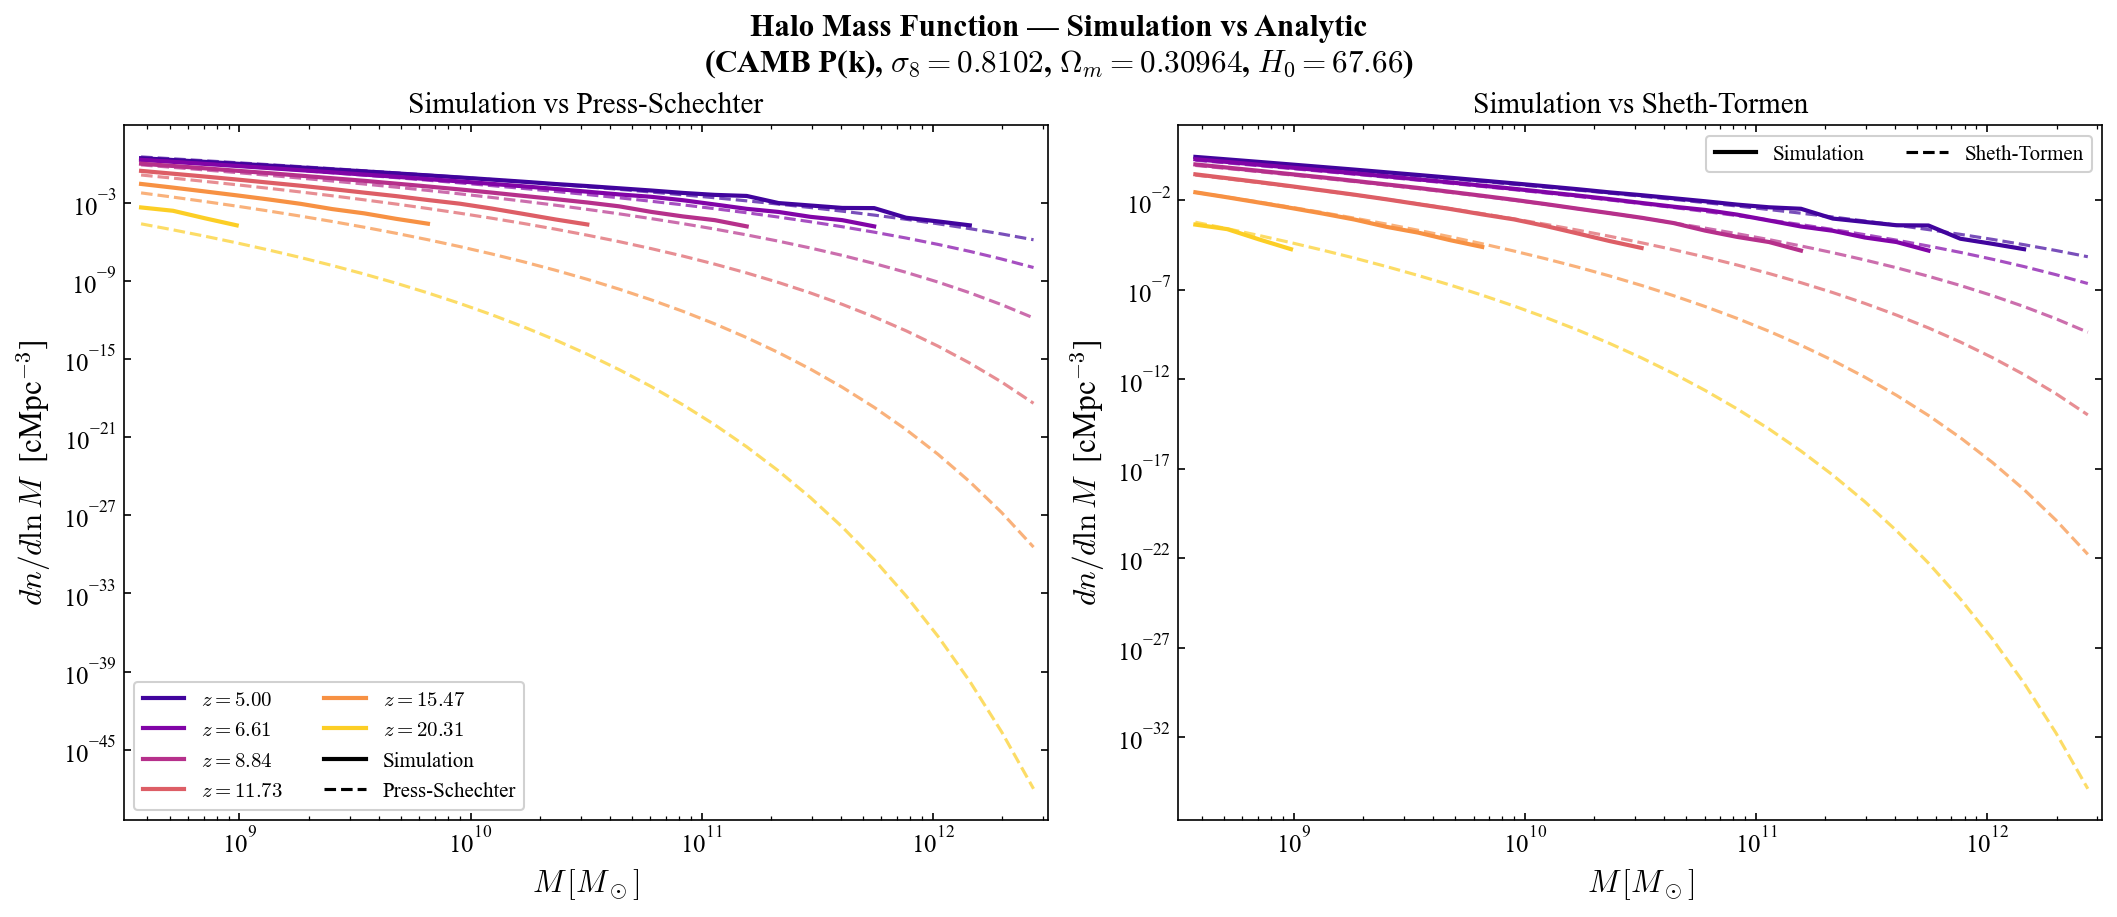

✓ Saved: hmf_camb.png / .pdf


In [70]:
# =============================================================================
# HMF vs Press-Schechter + Sheth-Tormen using CAMB for accurate σ(M)
# =============================================================================
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import os
import camb
from scipy.integrate import quad
from scipy.interpolate import interp1d
from astropy.cosmology import FlatLambdaCDM

PLOT_DIR = "lightcone_plots"
HALO_OUT = "lightcone_halos/catalogues"
os.makedirs(PLOT_DIR, exist_ok=True)

STYLE = {
    'font.family':         'serif',
    'font.serif':          ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset':    'cm',
    'font.size':           13,
    'axes.labelsize':      15,
    'axes.titlesize':      14,
    'xtick.labelsize':     12,
    'ytick.labelsize':     12,
    'xtick.direction':     'in',
    'ytick.direction':     'in',
    'xtick.top':           True,
    'ytick.right':         True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'figure.dpi':          150,
    'savefig.dpi':         300,
    'savefig.bbox':        'tight',
}

# ── cosmological parameters matching inputs ───────────────────────────────────
H0     = 67.66
h      = H0 / 100
ombh2  = 0.04897 * h**2
omch2  = (0.30964 - 0.04897) * h**2
ns     = 0.9665
sigma8 = 0.8102
Om0    = 0.30964
BOX_LEN = float(inputs.simulation_options.BOX_LEN)
VOL     = BOX_LEN**3   # cMpc^3

cosmo_astropy = FlatLambdaCDM(H0=H0, Om0=Om0)
rho_mean_0    = Om0 * cosmo_astropy.critical_density0.to('M_sun/Mpc^3').value
# comoving mean density (independent of z)
print(f"rho_mean_0 = {rho_mean_0:.4e} M_sun/cMpc^3")

# =============================================================================
# STEP 1: compute P(k) with CAMB at z=0, then get σ(R) by integration
# =============================================================================
print("Running CAMB...")
pars = camb.CAMBparams()
pars.set_cosmology(
    H0=H0,
    ombh2=ombh2,
    omch2=omch2,
    omk=0,
    tau=0.054,
)
pars.InitPower.set_params(ns=ns, As=2.1e-9)
pars.set_matter_power(redshifts=[0.0], kmax=1000.0)

from camb import model
pars.NonLinear = model.NonLinear_none


results  = camb.get_results(pars)
kh, _, pk = results.get_matter_power_spectrum(
    minkh=1e-4, maxkh=1e4, npoints=500
)
pk = pk[0]   # z=0

# normalise to sigma8
def sigma_R_raw(R, kh, pk):
    """σ(R) from P(k) via top-hat window integral."""
    def integrand(lnk):
        k  = np.exp(lnk)
        kR = k * R
        W  = 3 * (np.sin(kR) - kR * np.cos(kR)) / kR**3
        pk_interp = np.interp(k / h, kh, pk)   # kh in h/Mpc, pk in (Mpc/h)^3
        # convert: P(k [1/Mpc]) = P(k [h/Mpc]) / h^3
        pk_mpc = pk_interp / h**3
        return k**3 * pk_mpc * W**2 / (2 * np.pi**2)
    val, _ = quad(integrand, np.log(1e-4), np.log(1e4), limit=200)
    return np.sqrt(val)

# compute σ(8 Mpc/h) for normalisation
sigma8_raw = sigma_R_raw(8.0 / h, kh, pk)
norm       = sigma8 / sigma8_raw
print(f"σ8 raw = {sigma8_raw:.4f}, target = {sigma8}, norm = {norm:.4f}")

# precompute σ(R) on a grid and interpolate — much faster than integrating each time
print("Computing σ(R) grid...")
R_grid     = np.logspace(-2, 3, 200)   # Mpc
sigma_grid = np.array([norm * sigma_R_raw(R, kh, pk) for R in R_grid])
sigma_interp = interp1d(np.log(R_grid), np.log(sigma_grid),
                        kind='cubic', fill_value='extrapolate')

def sigma_M(M_msun, z):
    """σ(M) at redshift z using linear growth factor."""
    R = (3 * M_msun / (4 * np.pi * rho_mean_0)) ** (1/3)   # cMpc = Mpc here
    s0 = np.exp(sigma_interp(np.log(R)))   # σ at z=0
    # linear growth factor D(z) ≈ accurate fit for flat ΛCDM
    Omz = cosmo_astropy.Om(z)
    gz  = (5/2) * Omz / (Omz**(4/7) - (1 - Omz) + (1 + Omz/2) * (1 + (1-Omz)/70))
    g0  = (5/2) * Om0 / (Om0**(4/7) - (1 - Om0) + (1 + Om0/2) * (1 + (1-Om0)/70))
    Dz  = gz / (g0 * (1 + z))
    return s0 * Dz

def dlnsigma_dlnM(M_msun, z, dlogM=0.01):
    """Numerical derivative d ln σ / d ln M."""
    M1 = M_msun * 10**( dlogM)
    M2 = M_msun * 10**(-dlogM)
    return (np.log(sigma_M(M1, z)) - np.log(sigma_M(M2, z))) / (2 * dlogM * np.log(10))

# =============================================================================
# STEP 2: HMF multiplicity functions
# =============================================================================
def f_press_schechter(nu):
    """PS multiplicity f(ν) = sqrt(2/π) ν exp(-ν²/2)."""
    return np.sqrt(2/np.pi) * nu * np.exp(-nu**2 / 2)

def f_sheth_tormen(nu, a=0.707, p=0.3, A=0.3222):
    """ST multiplicity f(ν) — better fit to simulations."""
    nu2 = a * nu**2
    return A * np.sqrt(2 * nu2 / np.pi) * (1 + nu2**(-p)) * np.exp(-nu2 / 2)

def hmf(M_msun, z, multiplicity='ST', delta_c=1.686):
    """
    HMF: dn/d(lnM) [cMpc^-3]
    multiplicity: 'PS' or 'ST'
    """
    s      = sigma_M(M_msun, z)
    nu     = delta_c / s
    dlnsdlnM = dlnsigma_dlnM(M_msun, z)

    if multiplicity == 'PS':
        f = f_press_schechter(nu)
    else:
        f = f_sheth_tormen(nu)

    return (rho_mean_0 / M_msun) * f * np.abs(dlnsdlnM)

# =============================================================================
# STEP 3: load catalogues and plot
# =============================================================================
halo_files    = sorted(
    [f for f in os.listdir(HALO_OUT) if f.startswith('masses')],
    key=lambda f: float(f.replace('masses_z','').replace('.npy',''))
)
node_z_sorted = [float(f.replace('masses_z','').replace('.npy',''))
                 for f in halo_files]

idx_pick = np.linspace(0, len(node_z_sorted)-1, 6, dtype=int)
z_pick   = [node_z_sorted[i] for i in idx_pick]

M_bins  = np.logspace(8.5, 12.5, 30)
M_cents = 0.5 * (M_bins[:-1] + M_bins[1:])
dlnM    = np.diff(np.log(M_bins))
colors  = plt.cm.plasma(np.linspace(0.1, 0.9, len(z_pick)))

print("Computing HMFs...")
with mpl.rc_context(STYLE):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

    for color, z_node in zip(colors, z_pick):
        tag    = f"z{z_node:.4f}"
        masses = np.load(os.path.join(HALO_OUT, f"masses_{tag}.npy"))
        if len(masses) == 0:
            continue

        # measured HMF
        counts, _ = np.histogram(masses, bins=M_bins)
        hmf_sim   = counts / (VOL * dlnM)
        good      = counts >= 5

        # theory HMFs
        hmf_ps = np.array([hmf(M, z_node, 'PS') for M in M_cents])
        hmf_st = np.array([hmf(M, z_node, 'ST') for M in M_cents])

        label = f"$z={z_node:.2f}$"

        for ax, theory, ls, lw in zip(
            [axes[0], axes[1]],
            [hmf_ps,  hmf_st],
            ['--',    '--'],
            [1.5,     1.5],
        ):
            ax.plot(M_cents[good], hmf_sim[good],
                    color=color, lw=2, label=label if ax is axes[0] else None)
            ax.plot(M_cents, theory,
                    color=color, lw=lw, ls=ls, alpha=0.7)

    for ax, title in zip(axes, ["Press-Schechter", "Sheth-Tormen"]):
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(r'$M\,[M_\odot]$',             fontsize=15)
        ax.set_ylabel(r'$dn/d\ln M$  [cMpc$^{-3}$]', fontsize=15)
        ax.set_title(f"Simulation vs {title}",        fontsize=14)
        ax.set_xlim(M_bins[0], M_bins[-1])
        #ax.grid(True, which='both', alpha=0.2)
        ax.plot([], [], 'k-',  lw=2,   label='Simulation')
        ax.plot([], [], 'k--', lw=1.5, label=title)
        ax.legend(fontsize=10, ncol=2, framealpha=0.9)

    fig.suptitle(
        "Halo Mass Function — Simulation vs Analytic\n"
        f"(CAMB P(k), $\\sigma_8={sigma8}$, "
        f"$\\Omega_m={Om0}$, $H_0={H0}$)",
        fontsize=15, fontweight='bold'
    )

    plt.savefig(os.path.join(PLOT_DIR, "hmf_camb.png"), dpi=300)
    plt.savefig(os.path.join(PLOT_DIR, "hmf_camb.pdf"))
    plt.show()
    print("✓ Saved: hmf_camb.png / .pdf")

In [ ]:
# =============================================================================
# TOP 2000 HALOS AT EACH NODE REDSHIFT (slab-filtered)
# =============================================================================
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

PLOT_DIR = "lightcone_plots"
HALO_OUT = "lightcone_halos/catalogues"
os.makedirs(PLOT_DIR, exist_ok=True)

STYLE = {
    'font.family':         'serif',
    'font.serif':          ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset':    'cm',
    'font.size':           14,
    'axes.labelsize':      16,
    'axes.titlesize':      16,
    'xtick.labelsize':     13,
    'ytick.labelsize':     13,
    'xtick.direction':     'in',
    'ytick.direction':     'in',
    'xtick.top':           True,
    'ytick.right':         True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'figure.dpi':          150,
    'savefig.dpi':         300,
    'savefig.bbox':        'tight',
}

BOX_LEN       = float(inputs.simulation_options.BOX_LEN)
HII_DIM       = inputs.simulation_options.HII_DIM
cell_size_mpc = BOX_LEN / HII_DIM
N_TOP         = 2000

# pre-compute lightcone distances in pixels once
lcpix = lightconer.get_lc_distances_in_pixels(inputs.simulation_options.cell_size)

# ── load catalogues sorted low-z → high-z ────────────────────────────────────
halo_files    = sorted(
    [f for f in os.listdir(HALO_OUT) if f.startswith('masses')],
    key=lambda f: float(f.replace('masses_z', '').replace('.npy', ''))
)
node_z_sorted = [float(f.replace('masses_z', '').replace('.npy', ''))
                 for f in halo_files]

if len(node_z_sorted) >= 6:
    idx_pick = np.linspace(0, len(node_z_sorted) - 1, 6, dtype=int)
else:
    idx_pick = np.arange(len(node_z_sorted))

z_pick = [node_z_sorted[i] for i in idx_pick]
print(f"Plotting z: {[f'{z:.3f}' for z in z_pick]}")

z_lc = lightcone.lightcone_redshifts

with mpl.rc_context(STYLE):
    ncols = 3
    nrows = int(np.ceil(len(z_pick) / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(6 * ncols, 5.5 * nrows),
                             constrained_layout=True)
    axes = np.array(axes).flatten()

    for ax, z_node in zip(axes, z_pick):

        # ── load catalogue ────────────────────────────────────────────────────
        tag    = f"z{z_node:.4f}"
        masses = np.load(os.path.join(HALO_OUT, f"masses_{tag}.npy"))
        coords = np.load(os.path.join(HALO_OUT, f"coords_{tag}.npy"))

        # ── find matching lightcone slice and z-cell ──────────────────────────
        z_idx  = np.argmin(np.abs(z_lc - z_node))
        from astropy.units import pixel
        lcidx  = int((lcpix.max() - lcpix[z_idx] + 1 * pixel).to_value(pixel))
        z_cell = (-lcidx + lightconer.index_offset) % HII_DIM
        z_lo   = z_cell * cell_size_mpc
        z_hi   = z_lo + cell_size_mpc

        # ── filter to slab, then take top N_TOP by mass ───────────────────────
        depth_mask = (coords[:, 2] >= z_lo) & (coords[:, 2] < z_hi)
        m_slab     = masses[depth_mask]
        c_slab     = coords[depth_mask]

        n_plot  = min(N_TOP, len(m_slab))
        top_idx = np.argsort(m_slab)[-n_plot:][::-1]
        m_top   = m_slab[top_idx]
        c_top   = c_slab[top_idx]

        print(f"  z={z_node:.3f}  z_cell={z_cell}  "
              f"slab=[{z_lo:.2f}, {z_hi:.2f}] cMpc  "
              f"in slab: {len(m_slab):,}  plotting top {n_plot:,}  "
              f"log10M: {np.log10(m_top.min()):.2f}–{np.log10(m_top.max()):.2f}")

        # ── density background ────────────────────────────────────────────────
        dens_sl = lightcone.lightcones['density'][:, :, z_idx].T
        vmin    = np.percentile(1 + dens_sl, 1)
        vmax    = np.percentile(1 + dens_sl, 99)

        im = ax.imshow(
            1 + dens_sl,
            origin='lower',
            extent=[0, BOX_LEN, 0, BOX_LEN],
            cmap='Greys',
            norm=mcolors.LogNorm(vmin=vmin, vmax=vmax),
            interpolation='bilinear',
        )
        plt.colorbar(im, ax=ax, label=r'$1+\delta$',
                     fraction=0.046, pad=0.15)

        # ── top halos scatter — co-spatial with density slice ─────────────────
        if len(m_top) > 0:
            sc = ax.scatter(
                c_top[:, 0], c_top[:, 1],
                c=np.log10(m_top),
                s=8,
                cmap='plasma',
                alpha=0.85,
                edgecolors='none',
                vmin=np.log10(m_top.min()),
                vmax=np.log10(m_top.max()),
            )
            plt.colorbar(sc, ax=ax,
                         label=r'$\log_{10}(M_\odot)$',
                         fraction=0.046, pad=0.04)

        ax.set_xlim(0, BOX_LEN)
        ax.set_ylim(0, BOX_LEN)
        ax.set_xlabel("x  [cMpc]")
        ax.set_ylabel("y  [cMpc]")
        ax.set_title(
            f"$z = {z_node:.3f}$   "
            f"top {n_plot:,} / {len(m_slab):,} halos in slab",
            fontsize=12
        )

    for ax in axes[len(z_pick):]:
        ax.set_visible(False)

    fig.suptitle(
        f"Top {N_TOP} most massive halos at node redshifts\n"
        f"(overlaid on density field, filtered to matching z-slab)",
        fontsize=15, fontweight='bold'
    )

    plt.savefig(os.path.join(PLOT_DIR, "top_halos_nodes.png"),
                dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(PLOT_DIR, "top_halos_nodes.pdf"),
                bbox_inches='tight')
    plt.show()
    print(f"\n✓ Saved: {PLOT_DIR}/top_halos_nodes.png / .pdf")

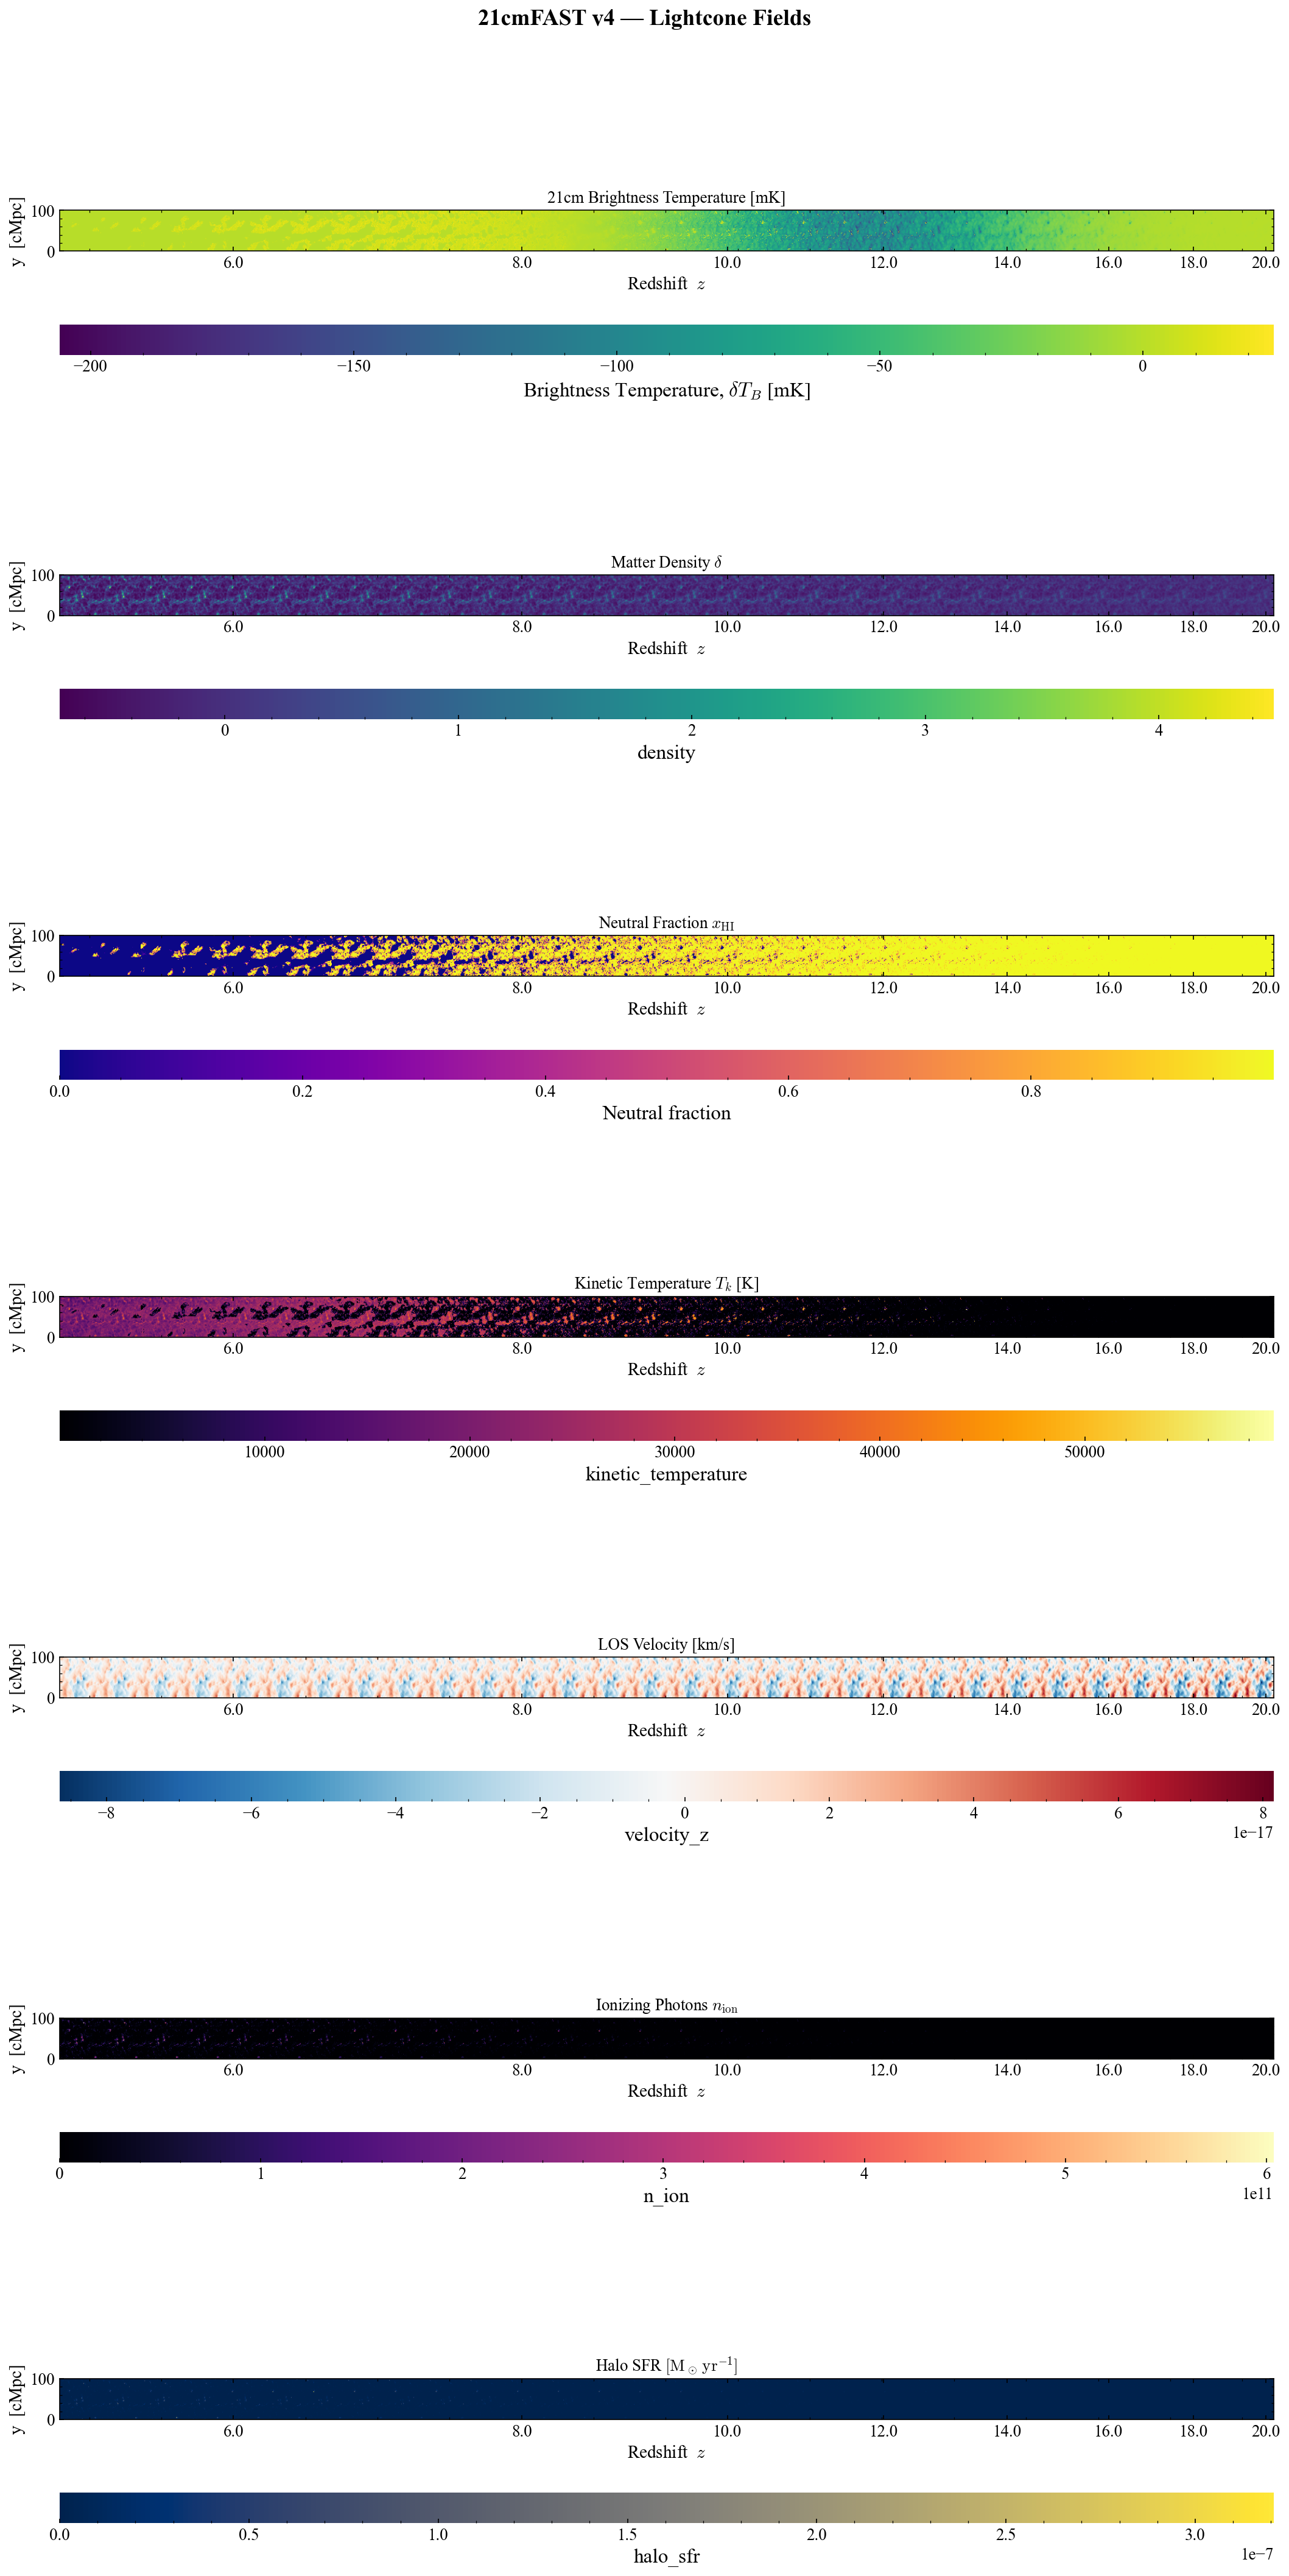

✓ Saved: all_lightcones.png / .pdf


In [2]:
# =============================================================================
# COMBINED LIGHTCONE FIELDS — all fields stacked
# =============================================================================
import matplotlib as mpl
import matplotlib.pyplot as plt
from py21cmfast import plotting
import os

PLOT_DIR = "lightcone_plots"
os.makedirs(PLOT_DIR, exist_ok=True)

STYLE = {
    'font.family':         'serif',
    'font.serif':          ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset':    'cm',
    'font.size':           14,
    'axes.labelsize':      16,
    'axes.titlesize':      16,
    'xtick.labelsize':     13,
    'ytick.labelsize':     13,
    'xtick.direction':     'in',
    'ytick.direction':     'in',
    'xtick.top':           True,
    'ytick.right':         True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'figure.dpi':          150,
    'savefig.dpi':         300,
    'savefig.bbox':        'tight',
}

fields_cfg = [
    ("brightness_temp",    "21cm Brightness Temperature [mK]",                        None),
    ("density",            r"Matter Density $\delta$",                                "viridis"),
    ("neutral_fraction",   r"Neutral Fraction $x_\mathrm{HI}$",                      "plasma"),
    ("kinetic_temperature",r"Kinetic Temperature $T_k$ [K]",                          "inferno"),
    ("velocity_z",         "LOS Velocity [km/s]",                                     "RdBu_r"),
    ("n_ion",              r"Ionizing Photons $n_\mathrm{ion}$",                      "magma"),
    ("halo_sfr",           r"Halo SFR $[\mathrm{M}_\odot\,\mathrm{yr}^{-1}]$",       "cividis"),
]

# filter to only fields actually present
available = [(f, l, c) for f, l, c in fields_cfg if f in lightcone.lightcones]
missing   = [f for f, _, _ in fields_cfg if f not in lightcone.lightcones]
if missing:
    print(f"  skipping (not in lightcone): {missing}")

with mpl.rc_context(STYLE):
    n    = len(available)
    fig, axes = plt.subplots(n, 1,
                             figsize=(14, 4 * n),
                             constrained_layout=True)
    if n == 1:
        axes = [axes]

    for ax, (field, label, cmap) in zip(axes, available):
        plotting.lightcone_sliceplot(lightcone, field, ax=ax, fig=fig, cmap=cmap)
        ax.set_xlabel("Redshift  $z$", fontsize=14)
        ax.set_ylabel("y  [cMpc]",     fontsize=14)
        ax.set_title(label,            fontsize=13, pad=6)

    fig.suptitle("21cmFAST v4 — Lightcone Fields",
                 fontsize=18, fontweight='bold')

    plt.savefig(os.path.join(PLOT_DIR, "all_lightcones.png"),
                dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(PLOT_DIR, "all_lightcones.pdf"),
                bbox_inches='tight')
    plt.show()
    print("✓ Saved: all_lightcones.png / .pdf")

In [3]:
# =============================================================================
# BUILD HALO LIGHTCONE ARRAYS (slab-correct)
# =============================================================================
import numpy as np
import os
from astropy.units import pixel

HALO_OUT      = "lightcone_halos/catalogues"
BOX_LEN       = float(inputs.simulation_options.BOX_LEN)
HII_DIM       = int(inputs.simulation_options.HII_DIM)
cell_size_mpc = BOX_LEN / HII_DIM
z_lc          = lightcone.lightcone_redshifts
n_lc          = len(z_lc)
lcpix         = lightconer.get_lc_distances_in_pixels(inputs.simulation_options.cell_size)
MASS_CUT      = 10.0**8.5

halo_files = sorted(
    [f for f in os.listdir(HALO_OUT) if f.startswith('masses')],
    key=lambda f: float(f.replace('masses_z', '').replace('.npy', ''))
)
node_z_sorted = np.array([
    float(f.replace('masses_z', '').replace('.npy', '')) for f in halo_files
])

print(f"Building slab-correct halo lightcone  "
      f"(mass cut > 10^{np.log10(MASS_CUT):.1f} M_sun)")
print(f"Loading {len(node_z_sorted)} catalogues...")

halo_mass_lc  = np.full((HII_DIM, HII_DIM, n_lc), np.nan, dtype=np.float32)
halo_count_lc = np.zeros((HII_DIM, HII_DIM, n_lc), dtype=np.float32)

for z_node in node_z_sorted:
    tag    = f"z{z_node:.4f}"
    masses = np.load(os.path.join(HALO_OUT, f"masses_{tag}.npy"))
    coords = np.load(os.path.join(HALO_OUT, f"coords_{tag}.npy"))

    # ── mass cut ──────────────────────────────────────────────────────────
    cut    = masses > MASS_CUT
    masses = masses[cut]
    coords = coords[cut]
    if len(masses) == 0:
        continue

    # ── find the lightcone slice index for this redshift ──────────────────
    z_idx  = np.argmin(np.abs(z_lc - z_node))

    # ── find the exact z-cell this lightcone slice samples ────────────────
    lcidx  = int((lcpix.max() - lcpix[z_idx] + 1 * pixel).to_value(pixel))
    z_cell = (-lcidx + lightconer.index_offset) % HII_DIM
    z_lo   = z_cell * cell_size_mpc
    z_hi   = z_lo + cell_size_mpc

    # ── slab filter ───────────────────────────────────────────────────────
    depth_mask = (coords[:, 2] >= z_lo) & (coords[:, 2] < z_hi)
    masses     = masses[depth_mask]
    coords     = coords[depth_mask]
    if len(masses) == 0:
        continue

    # ── bin into (x, y) grid ──────────────────────────────────────────────
    mass_map, _, _ = np.histogram2d(
        coords[:, 0], coords[:, 1],
        bins=HII_DIM,
        range=[[0, BOX_LEN], [0, BOX_LEN]],
        weights=masses,
    )
    count_map, _, _ = np.histogram2d(
        coords[:, 0], coords[:, 1],
        bins=HII_DIM,
        range=[[0, BOX_LEN], [0, BOX_LEN]],
    )

    # average mass per pixel
    with np.errstate(invalid='ignore', divide='ignore'):
        avg_map = np.where(count_map > 0, mass_map / count_map, np.nan)

    halo_mass_lc[:, :, z_idx]  = avg_map.T
    halo_count_lc[:, :, z_idx] = count_map.T

    print(f"  z={z_node:.3f}  z_cell={z_cell}  "
          f"slab=[{z_lo:.2f},{z_hi:.2f}]  "
          f"halos={len(masses):,}")

print(f"\n✓ halo_mass_lc  shape={halo_mass_lc.shape}  "
      f"filled={np.isfinite(halo_mass_lc).sum():,} pixels")
print(f"✓ halo_count_lc shape={halo_count_lc.shape}  "
      f"max count={halo_count_lc.max():.0f}")

Building slab-correct halo lightcone  (mass cut > 10^8.5 M_sun)
Loading 65 catalogues...
  z=5.000  z_cell=0  slab=[0.00,1.56]  halos=52,971
  z=5.120  z_cell=7  slab=[10.94,12.50]  halos=47,167
  z=5.242  z_cell=47  slab=[73.44,75.00]  halos=46,727
  z=5.367  z_cell=23  slab=[35.94,37.50]  halos=47,819
  z=5.495  z_cell=62  slab=[96.88,98.44]  halos=43,870
  z=5.625  z_cell=38  slab=[59.38,60.94]  halos=35,605
  z=5.757  z_cell=12  slab=[18.75,20.31]  halos=42,750
  z=5.892  z_cell=51  slab=[79.69,81.25]  halos=39,712
  z=6.030  z_cell=25  slab=[39.06,40.62]  halos=42,634
  z=6.171  z_cell=62  slab=[96.88,98.44]  halos=37,331
  z=6.314  z_cell=36  slab=[56.25,57.81]  halos=30,003
  z=6.460  z_cell=8  slab=[12.50,14.06]  halos=34,184
  z=6.609  z_cell=45  slab=[70.31,71.88]  halos=34,994
  z=6.762  z_cell=17  slab=[26.56,28.12]  halos=30,777
  z=6.917  z_cell=53  slab=[82.81,84.38]  halos=27,226
  z=7.075  z_cell=24  slab=[37.50,39.06]  halos=33,149
  z=7.237  z_cell=60  slab=[93.75,95

In [ ]:
# =============================================================================
# HMF vs PS + ST using CAMB σ(M), with BOX³ vs slab volume comparison
# Uses slab-correct z_cell from lightcone scheme
# =============================================================================
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import os
import camb
from camb import model
from scipy.integrate import quad
from scipy.interpolate import interp1d
from astropy.cosmology import FlatLambdaCDM
from astropy.units import pixel

PLOT_DIR = "lightcone_plots"
HALO_OUT = "lightcone_halos/catalogues"
os.makedirs(PLOT_DIR, exist_ok=True)

STYLE = {
    'font.family':         'serif',
    'font.serif':          ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset':    'cm',
    'font.size':           13,
    'axes.labelsize':      15,
    'axes.titlesize':      14,
    'xtick.labelsize':     12,
    'ytick.labelsize':     12,
    'xtick.direction':     'in',
    'ytick.direction':     'in',
    'xtick.top':           True,
    'ytick.right':         True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'figure.dpi':          150,
    'savefig.dpi':         300,
    'savefig.bbox':        'tight',
}

# ── cosmological parameters ───────────────────────────────────────────────────
H0     = 67.66
h      = H0 / 100
ombh2  = 0.04897 * h**2
omch2  = (0.30964 - 0.04897) * h**2
ns     = 0.9665
sigma8 = 0.8102
Om0    = 0.30964
BOX_LEN      = float(inputs.simulation_options.BOX_LEN)
HII_DIM      = int(inputs.simulation_options.HII_DIM)
cell_size_mpc = BOX_LEN / HII_DIM
z_lc         = lightcone.lightcone_redshifts
lcpix        = lightconer.get_lc_distances_in_pixels(
                   inputs.simulation_options.cell_size)
MASS_CUT     = 10.0**8.5

cosmo_astropy = FlatLambdaCDM(H0=H0, Om0=Om0)
rho_mean_0    = Om0 * cosmo_astropy.critical_density0.to('M_sun/Mpc^3').value
print(f"rho_mean_0 = {rho_mean_0:.4e} M_sun/cMpc^3")

# =============================================================================
# STEP 1: CAMB P(k) → σ(R) → σ(M)
# =============================================================================
print("Running CAMB...")
pars = camb.CAMBparams()
pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, omk=0, tau=0.054)
pars.InitPower.set_params(ns=ns, As=2.1e-9)
pars.set_matter_power(redshifts=[0.0], kmax=1000.0)

results      = camb.get_results(pars)
kh, _, pk    = results.get_matter_power_spectrum(
                   minkh=1e-4, maxkh=1e4, npoints=500)
pk = pk[0]

def sigma_R_raw(R, kh, pk):
    def integrand(lnk):
        k  = np.exp(lnk)
        kR = k * R
        W  = 3 * (np.sin(kR) - kR * np.cos(kR)) / kR**3
        pk_interp = np.interp(k / h, kh, pk)
        pk_mpc    = pk_interp / h**3
        return k**3 * pk_mpc * W**2 / (2 * np.pi**2)
    val, _ = quad(integrand, np.log(1e-4), np.log(1e4), limit=200)
    return np.sqrt(val)

sigma8_raw = sigma_R_raw(8.0 / h, kh, pk)
norm       = sigma8 / sigma8_raw
print(f"σ8 raw={sigma8_raw:.4f}  target={sigma8}  norm={norm:.4f}")

print("Computing σ(R) grid...")
R_grid       = np.logspace(-2, 3, 200)
sigma_grid   = np.array([norm * sigma_R_raw(R, kh, pk) for R in R_grid])
sigma_interp = interp1d(np.log(R_grid), np.log(sigma_grid),
                        kind='cubic', fill_value='extrapolate')

def sigma_M(M_msun, z):
    R   = (3 * M_msun / (4 * np.pi * rho_mean_0)) ** (1/3)
    s0  = np.exp(sigma_interp(np.log(R)))
    Omz = cosmo_astropy.Om(z)
    gz  = (5/2)*Omz / (Omz**(4/7) - (1-Omz) + (1+Omz/2)*(1+(1-Omz)/70))
    g0  = (5/2)*Om0 / (Om0**(4/7) - (1-Om0) + (1+Om0/2)*(1+(1-Om0)/70))
    Dz  = gz / (g0 * (1 + z))
    return s0 * Dz

def dlnsigma_dlnM(M_msun, z, dlogM=0.01):
    M1 = M_msun * 10**( dlogM)
    M2 = M_msun * 10**(-dlogM)
    return (np.log(sigma_M(M1,z)) - np.log(sigma_M(M2,z))) / (2*dlogM*np.log(10))

def f_press_schechter(nu):
    return np.sqrt(2/np.pi) * nu * np.exp(-nu**2/2)

def f_sheth_tormen(nu, a=0.707, p=0.3, A=0.3222):
    nu2 = a * nu**2
    return A * np.sqrt(2*nu2/np.pi) * (1 + nu2**(-p)) * np.exp(-nu2/2)

def hmf_theory(M_msun, z, multiplicity='ST', delta_c=1.686):
    s         = sigma_M(M_msun, z)
    nu        = delta_c / s
    dlnsdlnM  = dlnsigma_dlnM(M_msun, z)
    f         = f_sheth_tormen(nu) if multiplicity=='ST' else f_press_schechter(nu)
    return (rho_mean_0 / M_msun) * f * np.abs(dlnsdlnM)

# =============================================================================
# STEP 2: load catalogues + compute slab volumes using lightcone scheme
# =============================================================================
halo_files    = sorted(
    [f for f in os.listdir(HALO_OUT) if f.startswith('masses')],
    key=lambda f: float(f.replace('masses_z','').replace('.npy',''))
)
node_z_sorted = np.array([
    float(f.replace('masses_z','').replace('.npy','')) for f in halo_files
])

# pick 6 redshifts
idx_pick = np.linspace(0, len(node_z_sorted)-1, 6, dtype=int)
z_pick   = [node_z_sorted[i] for i in idx_pick]

M_bins  = np.logspace(8.5, 12.5, 30)
M_cents = 0.5 * (M_bins[:-1] + M_bins[1:])
dlnM    = np.diff(np.log(M_bins))
colors  = plt.cm.plasma(np.linspace(0.1, 0.9, len(z_pick)))

# compute slab thickness Δχ for each node using lightcone scheme
def get_slab_thickness(z_node):
    """
    Comoving slab thickness [cMpc] for this node redshift,
    using the same z_cell logic as the lightcone builder.
    """
    z_idx  = np.argmin(np.abs(z_lc - z_node))
    # find neighbouring lightcone slices
    z_lo   = z_lc[z_idx-1] if z_idx > 0            else z_lc[z_idx]
    z_hi   = z_lc[z_idx+1] if z_idx < len(z_lc)-1  else z_lc[z_idx]
    chi_lo = cosmo_astropy.comoving_distance(z_lo).to('Mpc').value
    chi_hi = cosmo_astropy.comoving_distance(z_hi).to('Mpc').value
    return abs(chi_hi - chi_lo) / 2.0   # half-interval on each side

def get_slab_masses(z_node):
    """Load masses filtered to the lightcone slab for this node."""
    tag    = f"z{z_node:.4f}"
    masses = np.load(os.path.join(HALO_OUT, f"masses_{tag}.npy"))
    coords = np.load(os.path.join(HALO_OUT, f"coords_{tag}.npy"))
    cut    = masses > MASS_CUT
    masses = masses[cut]
    coords = coords[cut]
    if len(masses) == 0:
        return masses

    # slab filter using lightcone z_cell scheme
    z_idx  = np.argmin(np.abs(z_lc - z_node))
    lcidx  = int((lcpix.max() - lcpix[z_idx] + 1*pixel).to_value(pixel))
    z_cell = (-lcidx + lightconer.index_offset) % HII_DIM
    z_lo   = z_cell * cell_size_mpc
    z_hi   = z_lo + cell_size_mpc

    depth_mask = (coords[:, 2] >= z_lo) & (coords[:, 2] < z_hi)
    return masses[depth_mask]

# =============================================================================
# STEP 3: plot — left: BOX³ volume, right: slab volume
# =============================================================================
print("Computing HMFs...")
print(f"\n{'z':>8}  {'V_box':>14}  {'dchi':>10}  {'V_slab':>14}  {'ratio':>8}")
print("-" * 60)

with mpl.rc_context(STYLE):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

    for color, z_node in zip(colors, z_pick):

        # ── full box masses ───────────────────────────────────────────────────
        tag         = f"z{z_node:.4f}"
        masses_full = np.load(os.path.join(HALO_OUT, f"masses_{tag}.npy"))
        cut         = masses_full > MASS_CUT
        masses_full = masses_full[cut]

        # ── slab masses ───────────────────────────────────────────────────────
        masses_slab = get_slab_masses(z_node)

        # ── volumes ───────────────────────────────────────────────────────────
        V_box  = BOX_LEN**3
        dchi   = get_slab_thickness(z_node)
        V_slab = BOX_LEN**2 * dchi

        print(f"{z_node:8.3f}  {V_box:14.1f}  {dchi:10.2f}  "
              f"{V_slab:14.1f}  {V_box/V_slab:8.2f}×")

        if len(masses_full) == 0:
            continue

        label = f"$z={z_node:.2f}$"

        # theory ST
        hmf_st = np.array([hmf_theory(M, z_node, 'ST') for M in M_cents])

        # ── left panel: BOX³ ─────────────────────────────────────────────────
        counts_full, _ = np.histogram(masses_full, bins=M_bins)
        hmf_box        = counts_full / (V_box * dlnM)
        good           = counts_full >= 5

        axes[0].plot(M_cents[good], hmf_box[good],
                     color=color, lw=2, label=label)
        axes[0].plot(M_cents, hmf_st,
                     color=color, lw=1.5, ls='--', alpha=0.7)

        # ── right panel: slab volume ──────────────────────────────────────────
        if len(masses_slab) > 0:
            counts_slab, _ = np.histogram(masses_slab, bins=M_bins)
            hmf_slab       = counts_slab / (V_slab * dlnM)
            good_slab      = counts_slab >= 5

            axes[1].plot(M_cents[good_slab], hmf_slab[good_slab],
                         color=color, lw=2, label=label)
            axes[1].plot(M_cents, hmf_st,
                         color=color, lw=1.5, ls='--', alpha=0.7)

    for ax, title, vol_str in zip(
        axes,
        ["Full box volume  $V = L^3$",
         r"Slab volume  $V = L^2\,\Delta\chi(z)$"],
        [f"$V = {BOX_LEN:.0f}^3 = {BOX_LEN**3:.2e}$ cMpc$^3$",
         r"$V = L^2\,\Delta\chi(z)$  per redshift"]
    ):
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(r'$M\,[M_\odot]$',              fontsize=15)
        ax.set_ylabel(r'$dn/d\ln M$  [cMpc$^{-3}$]',  fontsize=15)
        ax.set_title(title,                            fontsize=13)
        ax.set_xlim(M_bins[0], M_bins[-1])
        ax.plot([], [], 'k-',  lw=2,   label='Simulation')
        ax.plot([], [], 'k--', lw=1.5, label='Sheth-Tormen')
        ax.legend(fontsize=9, ncol=2, framealpha=0.9)
        ax.text(0.97, 0.97, vol_str,
                transform=ax.transAxes, ha='right', va='top',
                fontsize=10, bbox=dict(boxstyle='round', fc='white', alpha=0.8))

    fig.suptitle(
        "HMF: Full Box Volume vs Lightcone Slab Volume\n"
        f"CAMB P(k), Sheth-Tormen  |  "
        f"$\\sigma_8={sigma8}$, $\\Omega_m={Om0}$, $H_0={H0}$",
        fontsize=14, fontweight='bold'
    )

    plt.savefig(os.path.join(PLOT_DIR, "hmf_volume_comparison.png"),
                dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(PLOT_DIR, "hmf_volume_comparison.pdf"),
                bbox_inches='tight')
    plt.show()
    print("\n✓ Saved: hmf_volume_comparison.png / .pdf")


[X/4] HMF redshift evolution...
--------------------------------------------------


/tmp/ipykernel_2196866/1651766559.py:37: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  val, _ = quad(integrand, np.log(1e-4), np.log(1e4), limit=200)
/tmp/ipykernel_2196866/1651766559.py:37: IntegrationWarning: The maximum number of subdivisions (200) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  val, _ = quad(integrand, np.log(1e-4), np.log(1e4), limit=200)


  ✓ Saved: 05_hmf_redshift_evolution.png / .pdf


mid_x slice      : x index = 32
slice shape      : (64, 1905)
log10M range     : 8.50 – 9.84
filled pixels    : 1,874 / 121,920


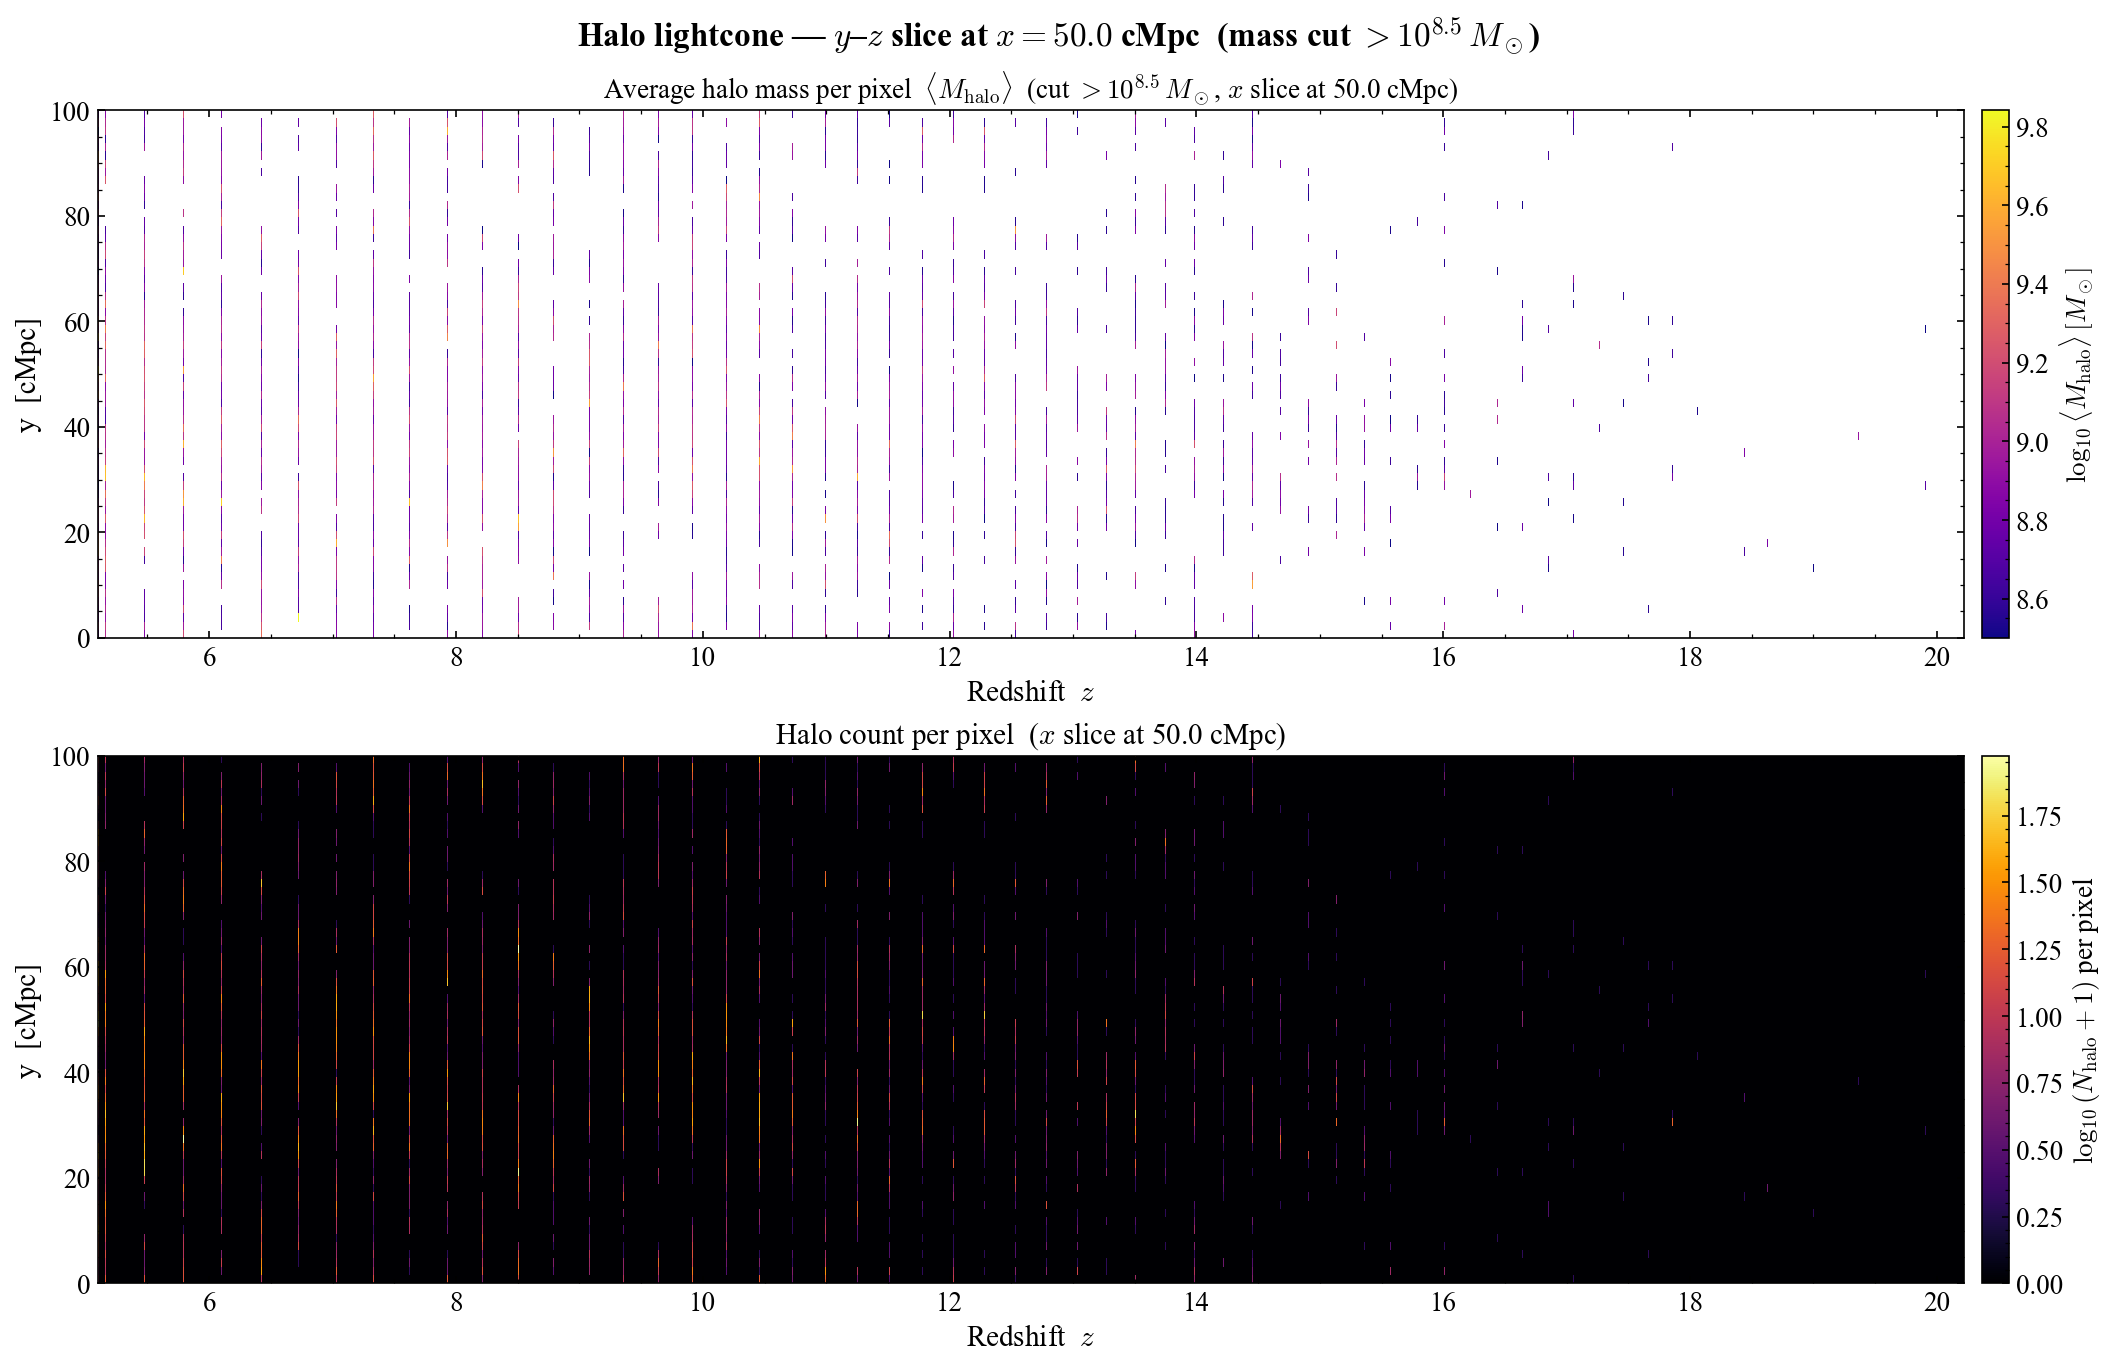

✓ Saved: halo_lightcone_midx_slice.png / .pdf


In [4]:
# =============================================================================
# HALO LIGHTCONE — middle x slice (y-z plane)
# =============================================================================
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import os

PLOT_DIR = "lightcone_plots"
os.makedirs(PLOT_DIR, exist_ok=True)

STYLE = {
    'font.family':         'serif',
    'font.serif':          ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset':    'cm',
    'font.size':           14,
    'axes.labelsize':      16,
    'axes.titlesize':      16,
    'xtick.labelsize':     13,
    'ytick.labelsize':     13,
    'xtick.direction':     'in',
    'ytick.direction':     'in',
    'xtick.top':           True,
    'ytick.right':         True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'figure.dpi':          150,
    'savefig.dpi':         300,
    'savefig.bbox':        'tight',
}

# ── single slice at mid x ─────────────────────────────────────────────────────
mid_x = HII_DIM // 2
halo_mass_slice  = halo_mass_lc[mid_x, :, :]    # (HII_DIM, n_slices) = (y, z)
halo_count_slice = halo_count_lc[mid_x, :, :]

extent = [z_lc[0], z_lc[-1], 0, BOX_LEN]

print(f"mid_x slice      : x index = {mid_x}")
print(f"slice shape      : {halo_mass_slice.shape}")
print(f"log10M range     : {np.log10(np.nanmin(halo_mass_slice[halo_mass_slice>0])):.2f} – "
      f"{np.log10(np.nanmax(halo_mass_slice)):.2f}")
print(f"filled pixels    : {np.isfinite(halo_mass_slice).sum():,} / "
      f"{halo_mass_slice.size:,}")

with mpl.rc_context(STYLE):
    fig, axes = plt.subplots(2, 1, figsize=(14, 9), constrained_layout=True)

    # panel 1: halo mass
    with np.errstate(invalid='ignore', divide='ignore'):
        log_mass = np.log10(halo_mass_slice)

    im1 = axes[0].imshow(
        log_mass,
        aspect='auto',
        origin='lower',
        cmap='plasma',
        extent=extent,
        interpolation='nearest',
    )
    cb1 = plt.colorbar(im1, ax=axes[0], pad=0.01, fraction=0.015)
    cb1.set_label(
        r'$\log_{10}\langle M_\mathrm{halo}\rangle\,[M_\odot]$',
        fontsize=13
    )
    axes[0].set_title(
        r"Average halo mass per pixel  $\langle M_\mathrm{halo}\rangle$  "
        f"(cut $> 10^{{{np.log10(MASS_CUT):.1f}}}\,M_\odot$, "
        f"$x$ slice at {mid_x * BOX_LEN / HII_DIM:.1f} cMpc)",
        fontsize=13
    )
    axes[0].set_xlabel("Redshift  $z$", fontsize=14)
    axes[0].set_ylabel("y  [cMpc]",     fontsize=14)

    # panel 2: halo count
    log_count = np.log10(halo_count_slice + 1)

    im2 = axes[1].imshow(
        log_count,
        aspect='auto',
        origin='lower',
        cmap='inferno',
        extent=extent,
        interpolation='nearest',
    )
    cb2 = plt.colorbar(im2, ax=axes[1], pad=0.01, fraction=0.015)
    cb2.set_label(
        r'$\log_{10}(N_\mathrm{halo}+1)$ per pixel',
        fontsize=13
    )
    axes[1].set_title(
        r"Halo count per pixel  "
        f"($x$ slice at {mid_x * BOX_LEN / HII_DIM:.1f} cMpc)",
        fontsize=14
    )
    axes[1].set_xlabel("Redshift  $z$", fontsize=14)
    axes[1].set_ylabel("y  [cMpc]",     fontsize=14)

    fig.suptitle(
        f"Halo lightcone — $y$–$z$ slice at $x = {mid_x * BOX_LEN / HII_DIM:.1f}$ cMpc  "
        f"(mass cut $> 10^{{{np.log10(MASS_CUT):.1f}}}\,M_\odot$)",
        fontsize=16, fontweight='bold'
    )

    plt.savefig(os.path.join(PLOT_DIR, "halo_lightcone_midx_slice.png"),
                dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(PLOT_DIR, "halo_lightcone_midx_slice.pdf"),
                bbox_inches='tight')
    plt.show()
    print("✓ Saved: halo_lightcone_midx_slice.png / .pdf")

/tmp/ipykernel_2196866/3569352532.py:34: RuntimeWarning: Mean of empty slice
  halo_mass_xavg  = np.nanmean(halo_mass_lc,  axis=0)   # (HII_DIM, n_slices)


x-averaged shape : (64, 1905)
log10M range     : 8.50 – 9.28
filled slices    : 65 / 1905


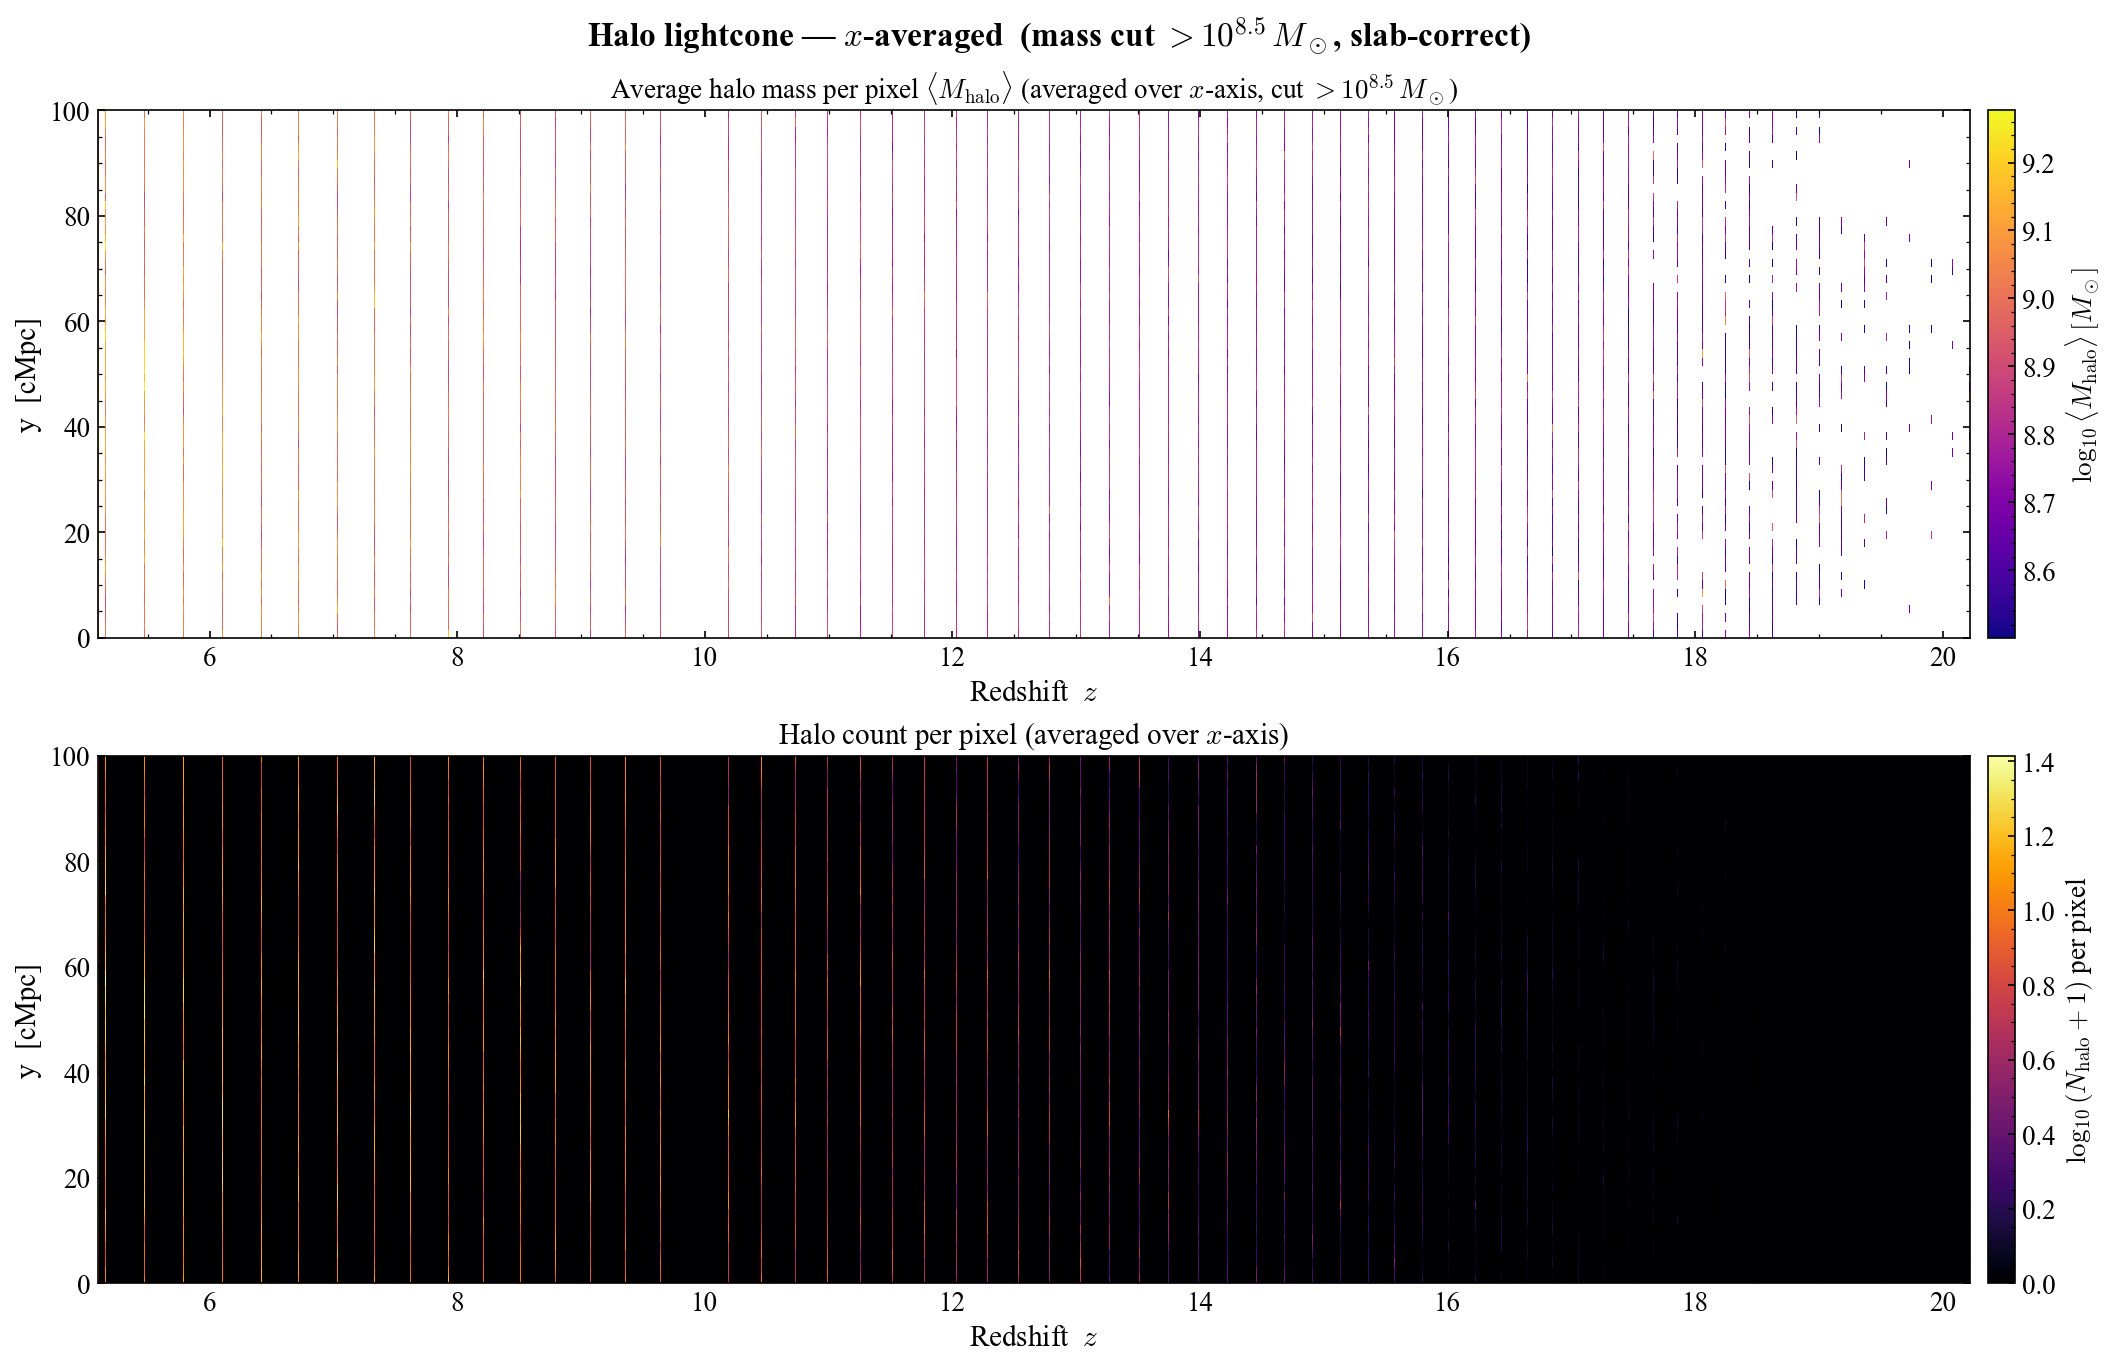

✓ Saved: halo_lightcone_xavg.png / .pdf


In [5]:
# =============================================================================
# HALO LIGHTCONE — x-averaged (y-z plane, slab-correct)
# =============================================================================
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import os

PLOT_DIR = "lightcone_plots"
os.makedirs(PLOT_DIR, exist_ok=True)

STYLE = {
    'font.family':         'serif',
    'font.serif':          ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset':    'cm',
    'font.size':           14,
    'axes.labelsize':      16,
    'axes.titlesize':      16,
    'xtick.labelsize':     13,
    'ytick.labelsize':     13,
    'xtick.direction':     'in',
    'ytick.direction':     'in',
    'xtick.top':           True,
    'ytick.right':         True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'figure.dpi':          150,
    'savefig.dpi':         300,
    'savefig.bbox':        'tight',
}

# ── average over x axis ───────────────────────────────────────────────────────
with np.errstate(invalid='ignore'):
    halo_mass_xavg  = np.nanmean(halo_mass_lc,  axis=0)   # (HII_DIM, n_slices)
    halo_count_xavg = np.nanmean(halo_count_lc, axis=0)   # (HII_DIM, n_slices)

extent = [z_lc[0], z_lc[-1], 0, BOX_LEN]

print(f"x-averaged shape : {halo_mass_xavg.shape}")
print(f"log10M range     : {np.log10(np.nanmin(halo_mass_xavg[halo_mass_xavg>0])):.2f} – "
      f"{np.log10(np.nanmax(halo_mass_xavg)):.2f}")
print(f"filled slices    : {np.isfinite(halo_mass_xavg).any(axis=0).sum()} / {halo_mass_xavg.shape[1]}")

with mpl.rc_context(STYLE):
    fig, axes = plt.subplots(2, 1, figsize=(14, 9), constrained_layout=True)

    # panel 1: halo mass
    with np.errstate(invalid='ignore', divide='ignore'):
        log_mass = np.log10(halo_mass_xavg)

    im1 = axes[0].imshow(
        log_mass,
        aspect='auto',
        origin='lower',
        cmap='plasma',
        extent=extent,
        interpolation='nearest',
    )
    cb1 = plt.colorbar(im1, ax=axes[0], pad=0.01, fraction=0.015)
    cb1.set_label(
        r'$\log_{10}\langle M_\mathrm{halo}\rangle\,[M_\odot]$',
        fontsize=13
    )
    axes[0].set_title(
        r"Average halo mass per pixel $\langle M_\mathrm{halo}\rangle$ "
        r"(averaged over $x$-axis, "
        f"cut $> 10^{{{np.log10(MASS_CUT):.1f}}}\,M_\odot$)",
        fontsize=13
    )
    axes[0].set_xlabel("Redshift  $z$", fontsize=14)
    axes[0].set_ylabel("y  [cMpc]",     fontsize=14)

    # panel 2: halo count
    log_count = np.log10(halo_count_xavg + 1)

    im2 = axes[1].imshow(
        log_count,
        aspect='auto',
        origin='lower',
        cmap='inferno',
        extent=extent,
        interpolation='nearest',
    )
    cb2 = plt.colorbar(im2, ax=axes[1], pad=0.01, fraction=0.015)
    cb2.set_label(
        r'$\log_{10}(N_\mathrm{halo}+1)$ per pixel',
        fontsize=13
    )
    axes[1].set_title(
        r"Halo count per pixel (averaged over $x$-axis)",
        fontsize=14
    )
    axes[1].set_xlabel("Redshift  $z$", fontsize=14)
    axes[1].set_ylabel("y  [cMpc]",     fontsize=14)

    fig.suptitle(
        f"Halo lightcone — $x$-averaged  "
        f"(mass cut $> 10^{{{np.log10(MASS_CUT):.1f}}}\,M_\odot$, slab-correct)",
        fontsize=16, fontweight='bold'
    )

    plt.savefig(os.path.join(PLOT_DIR, "halo_lightcone_xavg.png"),
                dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(PLOT_DIR, "halo_lightcone_xavg.pdf"),
                bbox_inches='tight')
    plt.show()
    print("✓ Saved: halo_lightcone_xavg.png / .pdf")

In [61]:
# =============================================================================
# LAE Generation Pipeline
# =============================================================================
import sys, os, numpy as np
from astropy.units import pixel
from astropy.cosmology import Planck18 as cosmo
from astropy import units as u
from astropy.constants import c as c_light
sys.path.insert(0, '/home/swanith/SiMPLE-Gen')

from SiMPLEGen.spec      import run_spec
from SiMPLEGen.abundance import run_abundance
from SiMPLEGen.assign    import run_assign
from SiMPLEGen.damping   import run_damping
from SiMPLEGen.config    import PATHS, HALO_CATALOGUE_DIR, MH_CUT, BOX_LEN, HII_DIM
import SiMPLEGen.config as cfg

# ── target redshift ────────────────────────────────────────────────────────
Z_TARGET = 7.0752   # change for each run: 5.6245, 6.6095, 7.0752

# ── box geometry ───────────────────────────────────────────────────────────
cell_size_mpc = BOX_LEN / HII_DIM
z_lc          = lightcone.lightcone_redshifts
n_los         = len(z_lc)
lcpix         = lightconer.get_lc_distances_in_pixels(
                    inputs.simulation_options.cell_size)
i_center      = n_los // 2
N_CELLS       = 64

# ── find closest node redshift and lightcone index ────────────────────────
z_idx  = np.argmin(np.abs(z_lc - Z_TARGET))
z_node = z_lc[z_idx]
print(f"Z_TARGET={Z_TARGET}  z_idx={z_idx}  z_node={z_node:.4f}")

# ── slab geometry in the raw box ──────────────────────────────────────────
lcidx  = int((lcpix.max() - lcpix[z_idx] + 1 * pixel).to_value(pixel))
z_cell = (-lcidx + lightconer.index_offset) % HII_DIM
z_lo   = z_cell * cell_size_mpc
z_hi   = z_lo + cell_size_mpc

print(f"Target z={Z_TARGET}  →  z_node={z_node:.3f}  z_cell={z_cell}")
print(f"slab=[{z_lo:.2f}, {z_hi:.2f}] cMpc")

# ── sightline window — centred on i_center AFTER rolling ──────────────────
lo_centre = i_center - N_CELLS // 2
hi_centre = i_center + N_CELLS // 2

# ── lightcone field arrays ─────────────────────────────────────────────────
xHI_lc  = lightcone.lightcones['neutral_fraction']
Tk_lc   = lightcone.lightcones['kinetic_temperature']
vz_lc   = lightcone.lightcones['velocity_z']
dens_lc = lightcone.lightcones['density']

# ── find closest saved catalogue snapshot ─────────────────────────────────
halo_files = sorted(
    [f for f in os.listdir(HALO_CATALOGUE_DIR) if f.startswith('masses')],
    key=lambda f: float(f.replace('masses_z','').replace('.npy',''))
)
node_z_sorted = np.array([
    float(f.replace('masses_z','').replace('.npy','')) for f in halo_files
])
snap_idx = np.argmin(np.abs(node_z_sorted - Z_TARGET))
z_snap   = node_z_sorted[snap_idx]
tag      = f"z{z_snap:.4f}"
print(f"Loading catalogue: {tag}")

# ── set config redshift BEFORE running any pipeline step ──────────────────
cfg.Z_REDSHIFT = float(z_snap)
print(f"cfg.Z_REDSHIFT set to: {cfg.Z_REDSHIFT:.4f}")

# ── load and filter catalogue ─────────────────────────────────────────────
masses = np.load(os.path.join(HALO_CATALOGUE_DIR, f"masses_{tag}.npy"))
coords = np.load(os.path.join(HALO_CATALOGUE_DIR, f"coords_{tag}.npy"))

mass_mask  = masses >= 10.0**MH_CUT
masses     = masses[mass_mask];  coords = coords[mass_mask]
depth_mask = (coords[:,2] >= z_lo) & (coords[:,2] < z_hi)
masses     = masses[depth_mask]; coords = coords[depth_mask]
print(f"Halos after cuts: {len(masses):,}")

# ── extract sightlines ────────────────────────────────────────────────────
xi = np.clip((coords[:,0]/cell_size_mpc).astype(int), 0, HII_DIM-1)
yi = np.clip((coords[:,1]/cell_size_mpc).astype(int), 0, HII_DIM-1)

# roll so halo's z_idx lands at i_center, then slice around i_center
shift     = i_center - z_idx

xHI_snap  = np.roll(xHI_lc[xi,yi,:],  shift, axis=1)[:,lo_centre:hi_centre].astype(np.float32)
Tk_snap   = np.roll(Tk_lc[xi,yi,:],   shift, axis=1)[:,lo_centre:hi_centre].astype(np.float32)
vpec_snap = np.roll(vz_lc[xi,yi,:],   shift, axis=1)[:,lo_centre:hi_centre].astype(np.float32)
dens_snap = np.roll(dens_lc[xi,yi,:], shift, axis=1)[:,lo_centre:hi_centre].astype(np.float32)

print(f"Sightline shape : {xHI_snap.shape}")
print(f"xHI mean        : {xHI_snap.mean():.4f}  (expect ~0.05 at z=5.6)")
print(f"xHI range       : {xHI_snap.min():.4f} – {xHI_snap.max():.4f}")

# ── unit conversion 1: neutral fraction → n_HI [cm^-3] ───────────────────
rho_crit = cosmo.critical_density(z_snap).to(u.g/u.cm**3).value
Ob        = cosmo.Ob0
mp        = 1.6726e-24   # proton mass [g]
nH_mean   = (rho_crit * Ob * (1 + z_snap)**3) / mp
nHI_snap  = nH_mean * (1 + dens_snap) * xHI_snap
print(f"n_HI range      : {nHI_snap.min():.3e} – {nHI_snap.max():.3e} cm^-3")

# ── unit conversion 2: velocity Mpc/s → km/s ─────────────────────────────
vpec_snap = vpec_snap * 3.086e19
print(f"vpec range      : {vpec_snap.min():.2f} – {vpec_snap.max():.2f} km/s")

# ── x_sim: relative box coordinates in Mpc/h ─────────────────────────────
h            = cosmo.h
BOX_SIZE_mph = BOX_LEN * h
x_sim_snap   = np.linspace(0, BOX_SIZE_mph, N_CELLS + 1)[:-1]
print(f"x_sim range (Mpc/h): {x_sim_snap.min():.2f} – {x_sim_snap.max():.2f}")

# ── z_grid: built analytically centred on z_snap (matching gen.py) ────────
H_z       = cosmo.H(z_snap).to(u.km/u.s/u.Mpc).value
dzdx      = H_z / c_light.to(u.km/u.s).value   # dz per Mpc/h

z_grid_snap = np.zeros(N_CELLS)
z_grid_snap[N_CELLS//2] = z_snap
for i in range(N_CELLS//2 - 1, -1, -1):
    z_grid_snap[i] = z_grid_snap[i+1] - (x_sim_snap[i+1] - x_sim_snap[i]) * dzdx
for i in range(N_CELLS//2 + 1, N_CELLS):
    z_grid_snap[i] = z_grid_snap[i-1] + (x_sim_snap[i] - x_sim_snap[i-1]) * dzdx

print(f"z_grid range  : {z_grid_snap.min():.4f} – {z_grid_snap.max():.4f}")
print(f"z_grid centre : {z_grid_snap[N_CELLS//2]:.4f}  (should be {z_snap:.4f})")

# ── save for pipeline ─────────────────────────────────────────────────────
np.save(PATHS["n_HI_halo"],  nHI_snap)
np.save(PATHS["T_halo"],     Tk_snap)
np.save(PATHS["v_pec_halo"], vpec_snap)
np.save(PATHS["halomass"],   masses)
np.save(PATHS["x_sim"],      x_sim_snap)
np.save(PATHS["z_grid"],     z_grid_snap)

# ── verify ────────────────────────────────────────────────────────────────
print(f"\nVerification:")
print(f"  z_snap         : {z_snap:.4f}")
print(f"  z_grid centre  : {z_grid_snap[N_CELLS//2]:.4f}")
print(f"  cfg.Z_REDSHIFT : {cfg.Z_REDSHIFT:.4f}")

# ── run pipeline ──────────────────────────────────────────────────────────
print("\n[spec]...")
run_spec()

tau_check = np.load(PATHS["tau_halo"])
print(f"  tau range : {tau_check.min():.3e} – {tau_check.max():.3e}")
print(f"  tau mean  : {tau_check.mean():.3e}")

print("[abundance]...")
run_abundance()

print("[assign]...")
run_assign()

print("[damping]...")
run_damping()

# ── quick LAE count ───────────────────────────────────────────────────────
LLya_obs_quick = LLya * damping
LAE_mask_quick = (REW >= 10.0) & (LLya_obs_quick >= 1e42) & (damping > 0)
print(f"\n  LAE candidates (REW>10, Lobs>1e42): {LAE_mask_quick.sum():,} / {len(masses):,}")
print(f"  damping > 0.5 : {(damping > 0.5).sum():,}")
print(f"  log10(Lobs) range: {np.log10(LLya_obs_quick[LAE_mask_quick]).min():.2f} – "
      f"{np.log10(LLya_obs_quick[LAE_mask_quick]).max():.2f}")

# ── load results ──────────────────────────────────────────────────────────
tau     = np.load(PATHS["tau_halo"])
Muv     = np.load(PATHS["Muv_grid"])
LLya    = np.load(PATHS["LLya_grid"])
REW     = np.load(PATHS["REW_grid"])
damping = np.load(PATHS["damping"])

print(f"\n✓ Done!")
print(f"  tau     shape : {tau.shape}")
print(f"  Muv     range : {Muv.min():.1f} – {Muv.max():.1f}")
print(f"  LLya    range : {np.log10(LLya[LLya>0].min()):.1f} – {np.log10(LLya.max()):.1f}  log10(erg/s)")
print(f"  REW     range : {REW.min():.1f} – {REW.max():.1f}  Å")
print(f"  damping range : {damping.min():.3f} – {damping.max():.3f}")

# ── save results ──────────────────────────────────────────────────────────
os.makedirs("LAE_results", exist_ok=True)
np.save(f"LAE_results/LLya_z{z_snap:.4f}.npy",    LLya)
np.save(f"LAE_results/REW_z{z_snap:.4f}.npy",     REW)
np.save(f"LAE_results/damping_z{z_snap:.4f}.npy", damping)
np.save(f"LAE_results/masses_z{z_snap:.4f}.npy",  masses)
np.save(f"LAE_results/coords_z{z_snap:.4f}.npy",  coords)
np.save(f"LAE_results/Muv_z{z_snap:.4f}.npy",     Muv)
print(f"✓ Saved results for z={z_snap:.4f}")

Z_TARGET=7.0752  z_idx=536  z_node=7.0730
Target z=7.0752  →  z_node=7.073  z_cell=24
slab=[37.50, 39.06] cMpc
Loading catalogue: z7.0752
cfg.Z_REDSHIFT set to: 7.0752
Halos after cuts: 8,388
Sightline shape : (8388, 64)
xHI mean        : 0.3693  (expect ~0.05 at z=5.6)
xHI range       : 0.0000 – 0.9980
n_HI range      : 0.000e+00 – 3.078e-02 cm^-3
vpec range      : -2282.83 – 2952.80 km/s
x_sim range (Mpc/h): 0.00 – 66.60
z_grid range  : 6.9772 – 7.1702
z_grid centre : 7.0752  (should be 7.0752)

Verification:
  z_snap         : 7.0752
  z_grid centre  : 7.0752
  cfg.Z_REDSHIFT : 7.0752

[spec]...
[spec] halos=8388, LOS_Nx=64 → 128, vgrid=101
[spec] z_centre=7.07520, halo_chunk=32768
[spec] chunk 1/1: halos 0:8388
[spec]    τ computed+interp for 8388 halos in 28.6s
[spec] τ saved → /home/swanith/SiMPLE-Gen/SiMPLEGen/data/tau_halo.npy
  tau range : 0.000e+00 – 2.145e+09
  tau mean  : 1.811e+07
[abundance]...


/home/swanith/miniconda3/envs/p21v4py311/lib/python3.11/site-packages/hmf/density_field/transfer_models.py:232: UserWarning: 'extrapolate_with_eh' was not set. Defaulting to True, which is different behaviour than versions <=3.4.4. This warning may be removed in v4.0. Silence it by setting extrapolate_with_eh explicitly.
  warnings.warn(


[abundance] Saved Muv_grid → /home/swanith/SiMPLE-Gen/SiMPLEGen/data/Muv_grid.npy
[assign]...
[assign] sampled 0/8388 halos
[assign] Saved LLya → /home/swanith/SiMPLE-Gen/SiMPLEGen/data/LLya_grid.npy
[assign] Saved REW  → /home/swanith/SiMPLE-Gen/SiMPLEGen/data/REW_grid.npy
[damping]...
[damping] Saved damping ratio → /home/swanith/SiMPLE-Gen/SiMPLEGen/data/damping.npy

  LAE candidates (REW>10, Lobs>1e42): 19 / 8,388
  damping > 0.5 : 1,527
  log10(Lobs) range: 42.01 – 43.09

✓ Done!
  tau     shape : (8388, 101)
  Muv     range : -21.1 – -13.7
  LLya    range : 39.6 – 43.1  log10(erg/s)
  REW     range : -5.4 – 299.9  Å
  damping range : 0.000 – 1.000
✓ Saved results for z=7.0752


Total halos        : 8,388
LAE candidates     : 70  (0.8%)
LAE Muv range      : -19.9 – -16.7
LAE log10(LLya)    : 42.0 – 43.1  erg/s
LAE REW range      : 10.6 – 288.3  Å
LAE damping range  : 1.000 – 1.000
log10(L) range : 42.00 – 43.07


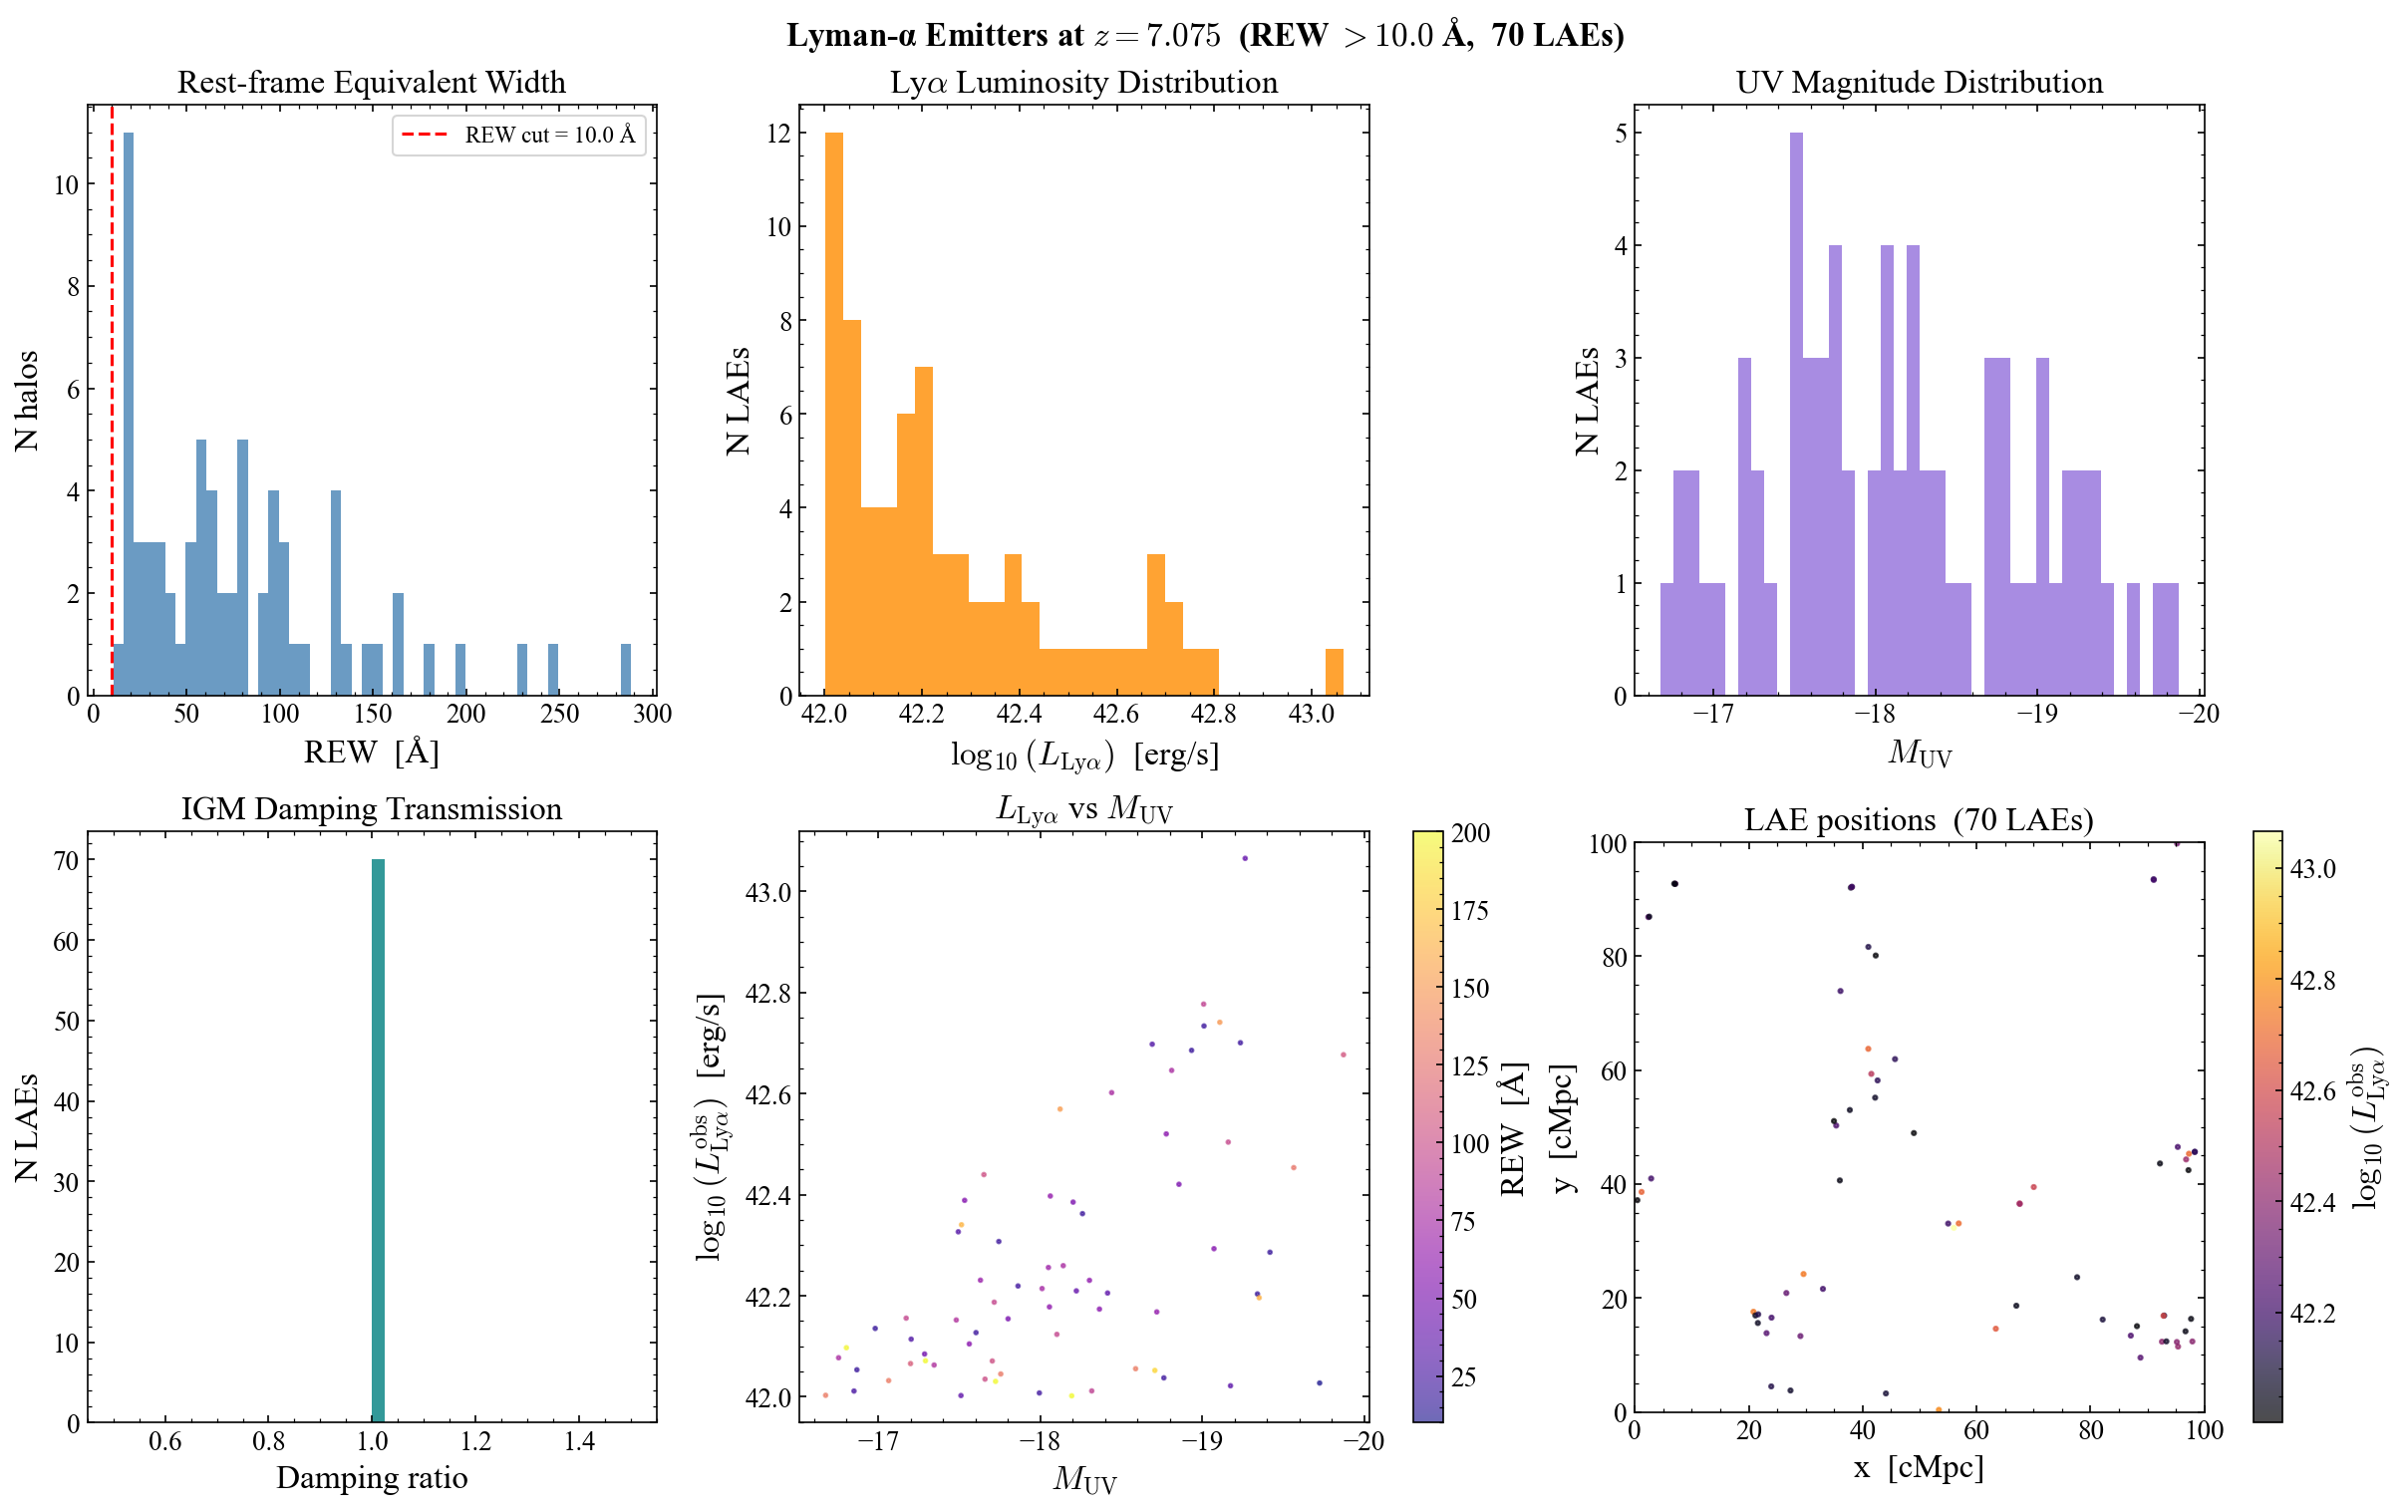

✓ Saved: LAE_z7.075.png / .pdf


In [28]:
# =============================================================================
# LAE SELECTION + PLOTS AT z=7.075
# =============================================================================
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import os

PLOT_DIR = "lightcone_plots"
os.makedirs(PLOT_DIR, exist_ok=True)

STYLE = {
    'font.family':         'serif',
    'font.serif':          ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset':    'cm',
    'font.size':           14,
    'axes.labelsize':      16,
    'axes.titlesize':      16,
    'xtick.labelsize':     13,
    'ytick.labelsize':     13,
    'xtick.direction':     'in',
    'ytick.direction':     'in',
    'xtick.top':           True,
    'ytick.right':         True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'figure.dpi':          150,
    'savefig.dpi':         300,
    'savefig.bbox':        'tight',
}

# ── LAE selection criteria ─────────────────────────────────────────────────
# Standard observational cuts:
#   1. REW > 20 Å  (strong Lyman-alpha line)
#   2. damping > 0 (transmission not fully suppressed)
#   3. LLya > 0    (positive luminosity)

REW_CUT  = 10.0   # Å
LLYA_CUT = 1e42    # erg/s
# ── observed luminosity after damping ──────────────────────────────────────
LLya_obs = LLya * damping   # attenuated by IGM damping wing
LAE_mask = (REW >= REW_CUT) & (LLya_obs >= LLYA_CUT) & (damping > 0)


print(f"Total halos        : {len(masses):,}")
print(f"LAE candidates     : {LAE_mask.sum():,}  "
      f"({100*LAE_mask.mean():.1f}%)")
print(f"LAE Muv range      : {Muv[LAE_mask].min():.1f} – {Muv[LAE_mask].max():.1f}")
print(f"LAE log10(LLya)    : {np.log10(LLya[LAE_mask]).min():.1f} – "
      f"{np.log10(LLya[LAE_mask]).max():.1f}  erg/s")
print(f"LAE REW range      : {REW[LAE_mask].min():.1f} – "
      f"{REW[LAE_mask].max():.1f}  Å")
print(f"LAE damping range  : {damping[LAE_mask].min():.3f} – "
      f"{damping[LAE_mask].max():.3f}")
print(f"log10(L) range : {np.log10(LLya_obs[LAE_mask]).min():.2f} – "
      f"{np.log10(LLya_obs[LAE_mask]).max():.2f}")


with mpl.rc_context(STYLE):
    fig, axes = plt.subplots(2, 3, figsize=(16, 10),
                             constrained_layout=True)

    # ── panel 1: REW distribution ─────────────────────────────────
    ax = axes[0, 0]
    ax.hist(REW[LAE_mask], bins=50, color='steelblue',
            edgecolor='none', alpha=0.8)
    ax.axvline(REW_CUT, color='r', ls='--', lw=1.5,
               label=f'REW cut = {REW_CUT} Å')
    ax.set_xlabel(r'REW  [Å]')
    ax.set_ylabel('N halos')
    ax.set_title('Rest-frame Equivalent Width')
    ax.legend(fontsize=11)

    # ── panel 2: Lya luminosity function ─────────────────────────
    ax = axes[0, 1]
    log_L = np.log10(LLya_obs[LAE_mask])
    bins  = np.linspace(log_L.min(), log_L.max(), 30)
    ax.hist(log_L, bins=bins, color='darkorange',
            edgecolor='none', alpha=0.8)
    ax.set_xlabel(r'$\log_{10}(L_{\rm Ly\alpha})$  [erg/s]')
    ax.set_ylabel('N LAEs')
    ax.set_title(r'Ly$\alpha$ Luminosity Distribution')

    # ── panel 3: UV magnitude distribution ───────────────────────
    ax = axes[0, 2]
    ax.hist(Muv[LAE_mask], bins=40, color='mediumpurple',
            edgecolor='none', alpha=0.8)
    ax.set_xlabel(r'$M_{\rm UV}$')
    ax.set_ylabel('N LAEs')
    ax.set_title('UV Magnitude Distribution')
    ax.invert_xaxis()

    # ── panel 4: damping ratio distribution ──────────────────────
    ax = axes[1, 0]
    ax.hist(damping[LAE_mask], bins=40, color='teal',
            edgecolor='none', alpha=0.8)
    ax.set_xlabel(r'Damping ratio')
    ax.set_ylabel('N LAEs')
    ax.set_title('IGM Damping Transmission')

    # ── panel 5: LLya_obs vs Muv ─────────────────────────────────
    ax = axes[1, 1]
    sc = ax.scatter(
        Muv[LAE_mask],
        np.log10(LLya_obs[LAE_mask]),
        c=REW[LAE_mask],
        s=3,
        cmap='plasma',
        alpha=0.6,
        vmin=REW_CUT,
        vmax=200,
    )
    plt.colorbar(sc, ax=ax, label='REW  [Å]')
    ax.set_xlabel(r'$M_{\rm UV}$')
    ax.set_ylabel(r'$\log_{10}(L_{\rm Ly\alpha}^{\rm obs})$  [erg/s]')
    ax.set_title(r'$L_{\rm Ly\alpha}$ vs $M_{\rm UV}$')
    ax.invert_xaxis()

    # ── panel 6: LAE positions in the box ────────────────────────
    ax = axes[1, 2]
    BOX_LEN_plot = float(inputs.simulation_options.BOX_LEN)
    sc2 = ax.scatter(
        coords[LAE_mask, 0],
        coords[LAE_mask, 1],
        c=np.log10(LLya_obs[LAE_mask]),
        s=4,
        cmap='inferno',
        alpha=0.7,
    )
    plt.colorbar(sc2, ax=ax,
                 label=r'$\log_{10}(L_{\rm Ly\alpha}^{\rm obs})$')
    ax.set_xlim(0, BOX_LEN_plot)
    ax.set_ylim(0, BOX_LEN_plot)
    ax.set_xlabel('x  [cMpc]')
    ax.set_ylabel('y  [cMpc]')
    ax.set_title(f'LAE positions  ({LAE_mask.sum():,} LAEs)')
    ax.set_aspect('equal')

    fig.suptitle(
        f"Lyman-α Emitters at $z = {z_snap:.3f}$  "
        f"(REW $> {REW_CUT}$ Å,  {LAE_mask.sum():,} LAEs)",
        fontsize=16, fontweight='bold'
    )

    plt.savefig(os.path.join(PLOT_DIR, f"LAE_z{z_snap:.3f}.png"),
                dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(PLOT_DIR, f"LAE_z{z_snap:.3f}.pdf"),
                bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: LAE_z{z_snap:.3f}.png / .pdf")

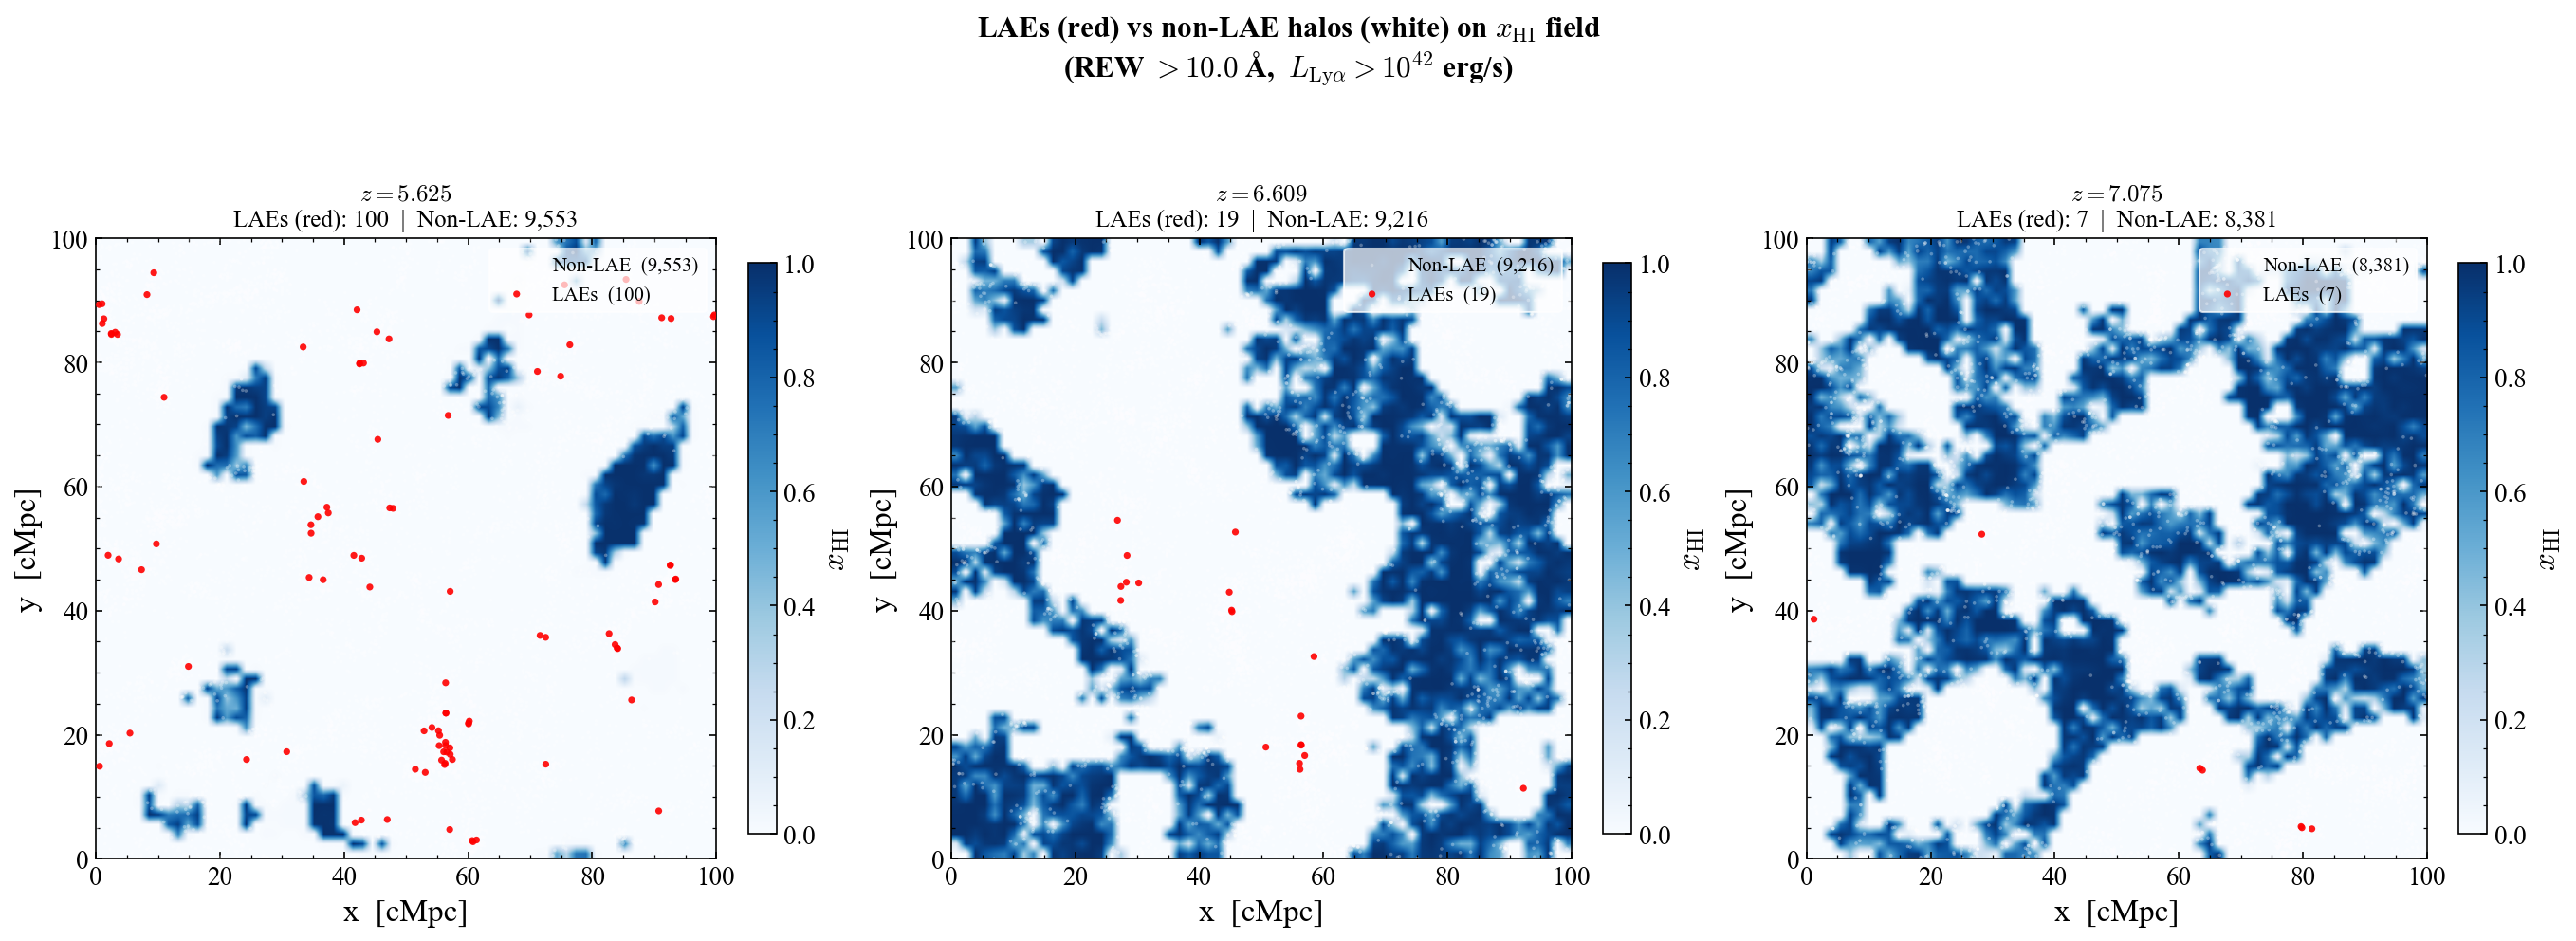

✓ Saved: LAE_overlay_all_z.png / .pdf


In [62]:
# =============================================================================
# LAE + NON-LAE HALOS ON xHI BACKGROUND — three redshifts
# =============================================================================
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

PLOT_DIR    = "lightcone_plots"
BOX_LEN_plot = float(inputs.simulation_options.BOX_LEN)
REW_CUT      = 10.0
LLYA_CUT     = 1e42

STYLE = {
    'font.family':         'serif',
    'font.serif':          ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset':    'cm',
    'font.size':           14,
    'axes.labelsize':      16,
    'axes.titlesize':      16,
    'xtick.labelsize':     13,
    'ytick.labelsize':     13,
    'xtick.direction':     'in',
    'ytick.direction':     'in',
    'xtick.top':           True,
    'ytick.right':         True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'figure.dpi':          150,
    'savefig.dpi':         300,
    'savefig.bbox':        'tight',
}

# ── redshifts to plot ─────────────────────────────────────────────────────
z_targets = [5.6245, 6.6095, 7.0752]

with mpl.rc_context(STYLE):
    fig, axes = plt.subplots(1, 3, figsize=(18, 7),
                             constrained_layout=True)

    for ax, z_s in zip(axes, z_targets):
        tag = f"{z_s:.4f}"

        # ── load saved results ─────────────────────────────────────────
        try:
            LLya_s    = np.load(f"LAE_results/LLya_z{tag}.npy")
            REW_s     = np.load(f"LAE_results/REW_z{tag}.npy")
            damping_s = np.load(f"LAE_results/damping_z{tag}.npy")
            masses_s  = np.load(f"LAE_results/masses_z{tag}.npy")
            coords_s  = np.load(f"LAE_results/coords_z{tag}.npy")
        except FileNotFoundError:
            ax.text(0.5, 0.5, f"z={z_s}\nnot yet run",
                    ha='center', va='center', transform=ax.transAxes)
            continue

        # ── LAE selection ──────────────────────────────────────────────
        LLya_obs_s = LLya_s * damping_s
        LAE_mask_s = (REW_s >= REW_CUT) & (LLya_obs_s >= LLYA_CUT) & (damping_s > 0)
        coords_lae_s    = coords_s[LAE_mask_s]
        coords_nonlae_s = coords_s[~LAE_mask_s]

        # ── xHI background at this redshift ───────────────────────────
        z_idx_plot = np.argmin(np.abs(z_lc - z_s))
        xHI_sl     = lightcone.lightcones['neutral_fraction'][:, :, z_idx_plot].T

        im = ax.imshow(
            xHI_sl,
            origin='lower',
            extent=[0, BOX_LEN_plot, 0, BOX_LEN_plot],
            cmap='Blues',
            vmin=0.0, vmax=1.0,
            interpolation='bilinear',
        )
        plt.colorbar(im, ax=ax, label=r'$x_{\rm HI}$',
                     fraction=0.046, pad=0.02)

        # non-LAE halos — white
        ax.scatter(
            coords_nonlae_s[:, 0], coords_nonlae_s[:, 1],
            s=3, color='white', alpha=0.3,
            edgecolors='none',
            label=f'Non-LAE  ({(~LAE_mask_s).sum():,})',
            zorder=2,
        )

        # LAE halos — red
        ax.scatter(
            coords_lae_s[:, 0], coords_lae_s[:, 1],
            s=12, color='red', alpha=0.9,
            edgecolors='none',
            label=f'LAEs  ({LAE_mask_s.sum():,})',
            zorder=3,
        )

        ax.set_xlim(0, BOX_LEN_plot)
        ax.set_ylim(0, BOX_LEN_plot)
        ax.set_xlabel('x  [cMpc]')
        ax.set_ylabel('y  [cMpc]')
        ax.set_aspect('equal')
        ax.legend(fontsize=10, loc='upper right',
                  framealpha=0.7, edgecolor='white')
        ax.set_title(
            f"$z = {z_s:.3f}$\n"
            f"LAEs (red): {LAE_mask_s.sum():,}  |  "
            f"Non-LAE: {(~LAE_mask_s).sum():,}",
            fontsize=12
        )

    fig.suptitle(
        f"LAEs (red) vs non-LAE halos (white) on $x_{{\\rm HI}}$ field\n"
        f"(REW $> {REW_CUT}$ Å,  $L_{{\\rm Ly\\alpha}} > 10^{{42}}$ erg/s)",
        fontsize=15, fontweight='bold'
    )

    plt.savefig(os.path.join(PLOT_DIR, "LAE_overlay_all_z.png"),
                dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(PLOT_DIR, "LAE_overlay_all_z.pdf"),
                bbox_inches='tight')
    plt.show()
    print("✓ Saved: LAE_overlay_all_z.png / .pdf")

V_eff = 15625.0 cMpc^3  per slab
  z=5.6245  LAEs=100  log10(L)=42.00–43.23
  z=6.6095  LAEs=19  log10(L)=42.01–43.09
  z=7.0752  LAEs=7  log10(L)=42.13–42.97


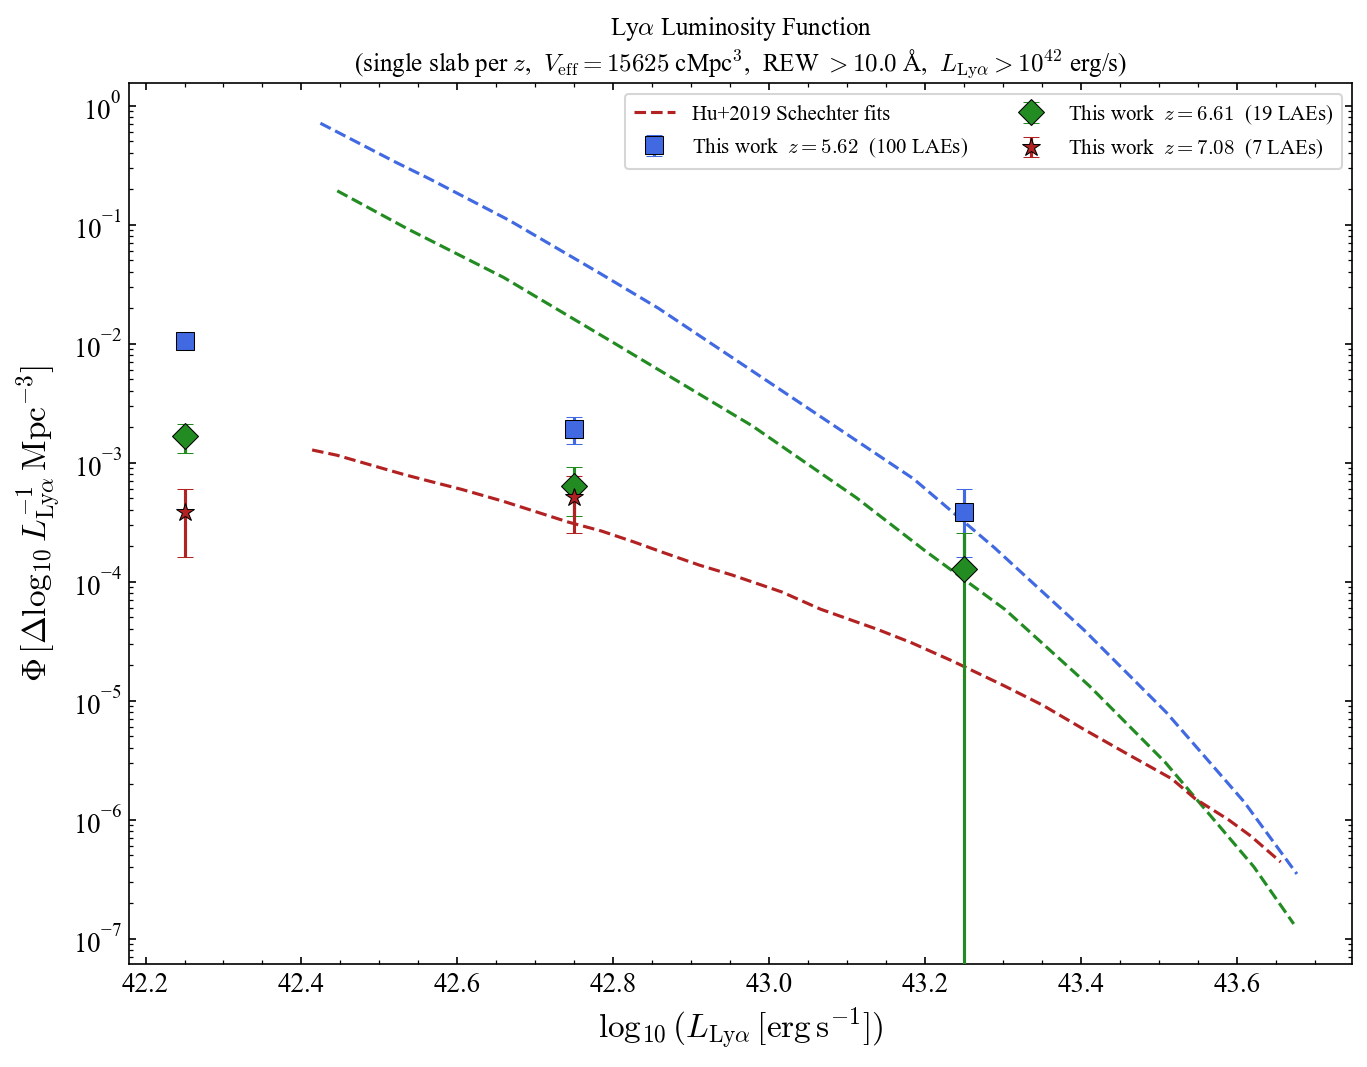

✓ Saved: LAE_LF_all_z_hu19.png / .pdf


In [64]:
# =============================================================================
# Lyman-alpha Luminosity Function — three redshifts vs Hu+2019
# =============================================================================
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import os

PLOT_DIR = "lightcone_plots"
os.makedirs(PLOT_DIR, exist_ok=True)

STYLE = {
    'font.family':         'serif',
    'font.serif':          ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset':    'cm',
    'font.size':           14,
    'axes.labelsize':      16,
    'axes.titlesize':      16,
    'xtick.labelsize':     13,
    'ytick.labelsize':     13,
    'xtick.direction':     'in',
    'ytick.direction':     'in',
    'xtick.top':           True,
    'ytick.right':         True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'figure.dpi':          150,
    'savefig.dpi':         300,
    'savefig.bbox':        'tight',
}

# ── simulation parameters ─────────────────────────────────────────────────
BOX_LEN_mpc   = float(inputs.simulation_options.BOX_LEN)
cell_size_mpc = BOX_LEN_mpc / int(inputs.simulation_options.HII_DIM)
V_eff         = BOX_LEN_mpc**2 * cell_size_mpc
REW_CUT       = 10.0
LLYA_CUT      = 1e42
bins          = np.arange(40.0, 44.5, 0.5)
bin_centres   = 0.5 * (bins[1:] + bins[:-1])
dlogL         = bins[1] - bins[0]

print(f"V_eff = {V_eff:.1f} cMpc^3  per slab")

# ── Hu+2019 Schechter fits ────────────────────────────────────────────────

# z~5.7
hu19_57_sch_x = np.array([
    42.42432432432433, 42.51891891891892, 42.564864864864866,
    42.66621621621621, 42.78243243243243, 42.858108108108105,
    43.018918918918914, 43.18513513513513, 43.28918918918917,
    43.404054054054036, 43.50945945945944, 43.60945945945944,
    43.67702702702701, 43.75405405405403, 43.795945945945924
])
hu19_57_sch_y = 10**np.array([
    -0.1481481481481488, -0.4691358024691361, -0.617283950617284,
    -0.9629629629629628, -1.4074074074074074, -1.7037037037037037,
    -2.4074074074074074, -3.1358024691358026, -3.7160493827160495,
    -4.407407407407407,  -5.098765432098766,  -5.851851851851852,
    -6.4567901234567895, -7.197530864197531,  -7.592592592592593
])

# z~6.6
hu19_66_sch_x = np.array([
    42.44594594594595, 42.53648648648649, 42.65945945945946,
    42.795945945945945, 42.97837837837837, 43.11216216216215,
    43.19999999999999,  43.30270270270269, 43.410810810810794,
    43.50810810810809,  43.6216216216216,  43.67297297297295,
    43.770270270270245
])
hu19_66_sch_y = 10**np.array([
    -0.7160493827160499, -1.0370370370370372, -1.4444444444444446,
    -1.975308641975309,  -2.691358024691358,  -3.2962962962962963,
    -3.740740740740741,  -4.234567901234568,  -4.8765432098765435,
    -5.518518518518518,  -6.395061728395062,  -6.876543209876543,
    -7.802469135802469
])

# z~7.0
hu19_70_sch_x = np.array([
    42.41369863013699,  42.445205479452056, 42.48493150684932,
    42.53150684931507,  42.56438356164384,  42.605479452054794,
    42.65890410958904,  42.74246575342465,  42.78493150684931,
    42.82739726027397,  42.864383561643834, 42.910958904109584,
    42.95205479452054,  43.01643835616438,  43.06575342465752,
    43.13835616438355,  43.18219178082191,  43.23561643835615,
    43.30136986301368,  43.350684931506834, 43.402739726027384,
    43.46164383561642,  43.516438356164365, 43.54657534246574,
    43.589041095890394, 43.61780821917806,  43.656164383561624
])
hu19_70_sch_y = 10**np.array([
    -2.89375, -2.9375,  -3.0125,  -3.1,     -3.15625, -3.225,
    -3.325,   -3.5,     -3.575,   -3.66875, -3.75625, -3.8625,
    -3.94375, -4.0875,  -4.23125, -4.4,     -4.5125,  -4.66875,
    -4.875,   -5.0375,  -5.2375,  -5.45625, -5.65625, -5.825,
    -6.0,     -6.1375,  -6.35625
])

# ── trim all Schechter fits to physical range ─────────────────────────────
mask_57 = hu19_57_sch_y > 1e-7
hu19_57_sch_x = hu19_57_sch_x[mask_57]
hu19_57_sch_y = hu19_57_sch_y[mask_57]

mask_66 = hu19_66_sch_y > 1e-7
hu19_66_sch_x = hu19_66_sch_x[mask_66]
hu19_66_sch_y = hu19_66_sch_y[mask_66]

mask_70 = hu19_70_sch_y > 1e-7
hu19_70_sch_x = hu19_70_sch_x[mask_70]
hu19_70_sch_y = hu19_70_sch_y[mask_70]

# ── plot ───────────────────────────────────────────────────────────────────
with mpl.rc_context(STYLE):
    fig, ax = plt.subplots(1, 1, figsize=(9, 7), constrained_layout=True)

    # Hu+2019 Schechter fits
    ax.plot(hu19_57_sch_x, hu19_57_sch_y,
            color='royalblue', lw=1.5, ls='--', zorder=2)
    ax.plot(hu19_66_sch_x, hu19_66_sch_y,
            color='forestgreen', lw=1.5, ls='--', zorder=2)
    ax.plot(hu19_70_sch_x, hu19_70_sch_y,
            color='firebrick', lw=1.5, ls='--', zorder=2,
            label='Hu+2019 Schechter fits')

    # ── our simulation LFs ────────────────────────────────────────────────
    sim_colors  = ['royalblue', 'forestgreen', 'firebrick']
    sim_markers = ['s', 'D', '*']
    sim_zsnaps  = [5.6245, 6.6095, 7.0752]

    for z_s, col, mk in zip(sim_zsnaps, sim_colors, sim_markers):
        tag = f"{z_s:.4f}"
        try:
            LLya_s    = np.load(f"LAE_results/LLya_z{tag}.npy")
            REW_s     = np.load(f"LAE_results/REW_z{tag}.npy")
            damping_s = np.load(f"LAE_results/damping_z{tag}.npy")
        except FileNotFoundError:
            print(f"  missing z={z_s} — skipping")
            continue

        LLya_obs_s = LLya_s * damping_s
        LAE_mask_s = (REW_s >= REW_CUT) & (LLya_obs_s >= LLYA_CUT) & (damping_s > 0)
        if LAE_mask_s.sum() == 0:
            print(f"  z={z_s}: no LAEs after cuts")
            continue

        log_L_s     = np.log10(LLya_obs_s[LAE_mask_s])
        counts_s, _ = np.histogram(log_L_s, bins=bins)
        phi_s       = counts_s / (V_eff * dlogL)
        phi_err_s   = np.sqrt(counts_s) / (V_eff * dlogL)
        detected_s  = counts_s > 0

        ax.errorbar(
            bin_centres[detected_s],
            phi_s[detected_s],
            yerr=phi_err_s[detected_s],
            fmt=mk, color=col,
            markersize=9, capsize=4, lw=1.5,
            markeredgecolor='k', markeredgewidth=0.5,
            label=f'This work  $z={z_s:.2f}$  ({LAE_mask_s.sum():,} LAEs)',
            zorder=5,
        )
        print(f"  z={z_s:.4f}  LAEs={LAE_mask_s.sum():,}  "
              f"log10(L)={log_L_s.min():.2f}–{log_L_s.max():.2f}")

    ax.set_yscale('log')
    ax.set_xlabel(r'$\log_{10}(L_{\rm Ly\alpha}\,[{\rm erg\,s^{-1}}])$')
    ax.set_ylabel(r'$\Phi\,[\Delta\log_{10}L_{\rm Ly\alpha}^{-1}\,{\rm Mpc^{-3}}]$')
    #ax.set_xlim(42.0, 44.0)
    #ax.set_ylim(1e-7, 1e-2)
    ax.legend(fontsize=10, ncol=2)
    ax.set_title(
        f"Ly$\\alpha$ Luminosity Function\n"
        f"(single slab per $z$,  $V_{{\\rm eff}}={V_eff:.0f}$ cMpc$^3$,  "
        f"REW $> {REW_CUT}$ Å,  $L_{{\\rm Ly\\alpha}} > 10^{{42}}$ erg/s)",
        fontsize=12
    )

    plt.savefig(os.path.join(PLOT_DIR, "LAE_LF_all_z_hu19.png"),
                dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(PLOT_DIR, "LAE_LF_all_z_hu19.pdf"),
                bbox_inches='tight')
    plt.show()
    print("✓ Saved: LAE_LF_all_z_hu19.png / .pdf")

In [66]:
LLya_56    = np.load("LAE_results/LLya_z5.6245.npy")
damping_56 = np.load("LAE_results/damping_z5.6245.npy")
REW_56     = np.load("LAE_results/REW_z5.6245.npy")

for cut in [1e42, 5e41, 1e41]:
    LLya_obs = LLya_56 * damping_56
    mask = (REW_56 >= 10) & (LLya_obs >= cut) & (damping_56 > 0)
    log_L = np.log10(LLya_obs[mask])
    counts, _ = np.histogram(log_L, bins=np.arange(40.0, 44.5, 0.5))
    print(f"\ncut={cut:.0e}  LAEs={mask.sum():,}")
    for bc, n in zip(0.5*(np.arange(40,44.5,0.5)[1:]+np.arange(40,44.5,0.5)[:-1]), counts):
        if n > 0:
            print(f"  log10(L)={bc:.2f}  N={n}")


cut=1e+42  LAEs=100
  log10(L)=42.25  N=82
  log10(L)=42.75  N=15
  log10(L)=43.25  N=3

cut=5e+41  LAEs=240
  log10(L)=41.75  N=140
  log10(L)=42.25  N=82
  log10(L)=42.75  N=15
  log10(L)=43.25  N=3

cut=1e+41  LAEs=1,482
  log10(L)=41.25  N=1071
  log10(L)=41.75  N=311
  log10(L)=42.25  N=82
  log10(L)=42.75  N=15
  log10(L)=43.25  N=3
